<figure>
  <img src="https://oficinavirtualderadicacion.sena.edu.co/oficinavirtual/Resources/logoSenaNaranja.png" width=150 height=150/>
  </center>
</figure>

# **Inspección de la estructura de datos**

In [ ]:
import kagglehub
import pandas as pd
import os
import re
import unicodedata
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from IPython.display import display, Image
warnings.filterwarnings('ignore')



warnings.filterwarnings('ignore')
# Descargar dataset
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Ruta del dataset:", path)

# Ver archivos
files = os.listdir(path)
print("Archivos:", files)

# Cargar datasets
customers = pd.read_csv(path + "/olist_customers_dataset.csv")
orders = pd.read_csv(path + "/olist_orders_dataset.csv")
order_items = pd.read_csv(path + "/olist_order_items_dataset.csv")
payments = pd.read_csv(path + "/olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + "/olist_order_reviews_dataset.csv")
products = pd.read_csv(path + "/olist_products_dataset.csv")
sellers = pd.read_csv(path + "/olist_sellers_dataset.csv")
geolocation = pd.read_csv(path + "/olist_geolocation_dataset.csv")
category_translation = pd.read_csv(path + "/product_category_name_translation.csv")


Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Ruta del dataset: /kaggle/input/brazilian-ecommerce
Archivos: ['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [ ]:
# Crear un diccionario con todos los datasets del proyecto Olist
# Esto permite automatizar el análisis sin repetir código
# y facilita escalar el análisis si se agregan más tablas
datasets = {
    "customers": customers,                    # Información de clientes
    "orders": orders,                          # Información de pedidos
    "order_items": order_items,                # Productos por pedido
    "payments": payments,                      # Información de pagos
    "reviews": reviews,                        # Reseñas de clientes
    "products": products,                      # Catálogo de productos
    "sellers": sellers,                        # Información de vendedores
    "geolocation": geolocation,                # Ubicaciones geográficas
    "category_translation": category_translation # Traducción de categorías
}

# Recorrer cada dataset para realizar auditoría estructural
for name, df in datasets.items():

    # Espacios para mejorar legibilidad del reporte
    print("\n")
    print("ANALISIS DEL DATASET:", name)
    print("\n")

    print("\nRESUMEN GENERAL DEL DATASET\n")

    # Crear tabla resumen con métricas principales
    resumen = pd.DataFrame({

        # Número total de registros
        "Filas": [df.shape[0]],

        # Número total de columnas
        "Columnas": [df.shape[1]],

        # Total de valores nulos en todo el dataset
        "Nulos Totales": [df.isnull().sum().sum()],

        # Cantidad de registros duplicados
        "Duplicados": [df.duplicated().sum()],

        # Memoria utilizada por el dataset
        # deep=True mide correctamente columnas tipo object
        "Memoria (KB)": [
            round(df.memory_usage(deep=True).sum() / 1024, 2)
        ]
    })

    # Mostrar resumen estructural
    display(resumen)

    print("\nTIPOS DE DATOS\n")

    # Mostrar tipo de dato declarado en pandas
    display(df.dtypes)

    print("\nPRIMERAS FILAS DEL DATASET\n")

    # Mostrar primeras filas para revisión rápida
    display(df.head())

    print("\nDESCRIPCION ESTADISTICA\n")

    # Mostrar estadísticas para variables numéricas
    # (media, desviación estándar, min, max, percentiles)
    display(df.describe())

    print("\nAUDITORIA COMPLETA POR COLUMNA\n")

    # Lista donde se almacenará el resumen por columna
    resumen_lista = []

    # Recorrer cada columna del dataset
    for col in df.columns:

        # Extraer datos de la columna
        col_data = df[col]

        # Detectar el tipo real de cada valor
        # Esto permite encontrar columnas con tipos mezclados
        tipos_serie = col_data.map(type)

        # Contar cuántos valores hay de cada tipo
        conteos = tipos_serie.value_counts()

        # Convertir tipos a string para mejor visualización
        conteos.index = conteos.index.map(str)

        # Calcular porcentaje de cada tipo
        porcentajes = tipos_serie.value_counts(normalize=True) * 100

        # Convertir índices a string
        porcentajes.index = porcentajes.index.map(str)

        # Contar valores nulos de la columna
        nulos = col_data.isnull().sum()

        # Construir reporte por tipo detectado
        for tipo_str in conteos.index:

            resumen_lista.append({

                # Nombre de la columna analizada
                "Columna": col,

                # Tipo real detectado en los valores
                "Tipo Detectado": tipo_str,

                # Cantidad de registros de ese tipo
                "Cantidad": conteos.loc[tipo_str],

                # Porcentaje dentro de la columna
                "Porcentaje": f"{porcentajes.loc[tipo_str]:.2f}%",

                # Cantidad de valores nulos
                "Nulos": nulos
            })

    # Convertir la lista en DataFrame estructurado
    # Esto crea una matriz de auditoría de tipos reales
    df_revelador = pd.DataFrame(resumen_lista)

    # Mostrar auditoría detallada
    display(df_revelador)



ANALISIS DEL DATASET: customers



RESUMEN GENERAL DEL DATASET



,Filas,Columnas,Nulos Totales,Duplicados,Memoria (KB)
0,99441,5,0,0,27224.48



TIPOS DE DATOS



,0
customer_id,object
customer_unique_id,object
customer_zip_code_prefix,int64
customer_city,object
customer_state,object



PRIMERAS FILAS DEL DATASET



...

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



DESCRIPCION ESTADISTICA



,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1



AUDITORIA COMPLETA POR COLUMNA



,Columna,Tipo Detectado,Cantidad,Porcentaje,Nulos
0,product_category_name,<class 'str'>,71,100.00%,0
1,product_category_name_english,<class 'str'>,71,100.00%,0


# **Auditoría de valores nulos y duplicados**

In [ ]:
# Imprimir título general del análisis de calidad de datos
# Esta sección evalúa completitud y duplicidad de los datasets
print('\nMATRIZ DE CALIDAD DE DATOS\n')

# ─────────────────────────────────────────────
# RESUMEN DE DUPLICADOS POR DATASET
# ─────────────────────────────────────────────

# Título de la sección
print('\nRESUMEN DE DUPLICADOS POR DATASET\n')

# Lista donde se almacenarán los resultados
dup_data = []

# Recorrer todos los datasets definidos
for name, df in datasets.items():

    # Contar registros duplicados exactos
    # duplicated() devuelve True para registros repetidos
    n_dup = df.duplicated().sum()

    # Calcular porcentaje de duplicados respecto al total
    pct_dup = round(n_dup / len(df) * 100, 2)

    # Guardar resultados en estructura tipo diccionario
    dup_data.append({
        'Dataset': name,
        'Total Filas': len(df),
        'Duplicados': n_dup,
        '% Duplicados': pct_dup
    })

# Convertir resultados en DataFrame para visualización estructurada
display(
    pd.DataFrame(dup_data)
    .set_index('Dataset')
)

# ─────────────────────────────────────────────
# MATRIZ DE CALIDAD (COMPLETITUD) POR COLUMNA
# ─────────────────────────────────────────────

# Recorrer cada dataset para analizar calidad por columna
for name, df in datasets.items():

    # Contar valores nulos por columna
    nulos = df.isnull().sum()

    # Calcular porcentaje de nulos por columna
    pct_nulos = (nulos / len(df) * 100).round(2)

    # Calcular porcentaje de completitud
    # (porcentaje de datos válidos)
    completitud = (100 - pct_nulos).round(2)

    # Obtener tipos de datos declarados
    tipo = df.dtypes

    # Construir matriz de calidad
    matriz = pd.DataFrame({

        # Nombre de columnas
        'Columna': df.columns,

        # Tipo de dato de cada columna
        'Tipo de Dato': tipo.values,

        # Número total de registros del dataset
        'Total Registros': len(df),

        # Cantidad de valores nulos
        'Valores Nulos': nulos.values,

        # Porcentaje de valores faltantes
        '% Nulos': pct_nulos.values,

        # Porcentaje de completitud
        '% Completitud': completitud.values,

        # Estado de calidad:
        # Completo → sin nulos
        # Incompleto → con nulos
        'Estado': [
            'Incompleto' if v > 0 else 'Completo'
            for v in nulos.values
        ]

    }).set_index('Columna')

    # Mostrar encabezado del dataset analizado
    print(f'\nMATRIZ DE CALIDAD — {name.upper()} \n')

    # Mostrar matriz de calidad
    display(matriz)

    # ─────────────────────────────────────────────
    # DETECCIÓN DE COLUMNAS CRÍTICAS
    # ─────────────────────────────────────────────

    # Identificar columnas con más del 30% de datos faltantes
    # Este umbral suele usarse como referencia en data quality
    criticos = matriz[
        matriz['% Nulos'] > 30
    ]

    # Si existen columnas críticas se genera alerta
    if not criticos.empty:

        print(
            f'ALERTA: Las siguientes columnas superan '
            f'el 30% de valores nulos:'
        )

        # Mostrar detalle de cada columna problemática
        for col, row in criticos.iterrows():

            print(
                f'     - {col}: {row["% Nulos"]}% nulos '
                f'({int(row["Valores Nulos"])} registros)'
            )


MATRIZ DE CALIDAD DE DATOS


RESUMEN DE DUPLICADOS POR DATASET



,Total Filas,Duplicados,% Duplicados
Dataset,,,
customers,99441,0,0.00
orders,99441,0,0.00
order_items,112650,0,0.00
payments,103886,0,0.00
reviews,99224,0,0.00
products,32951,0,0.00
sellers,3095,0,0.00
geolocation,1000163,261831,26.18
category_translation,71,0,0.00



MATRIZ DE CALIDAD — CUSTOMERS 



,Tipo de Dato,Total Registros,Valores Nulos,% Nulos,% Completitud,Estado
Columna,,,,,,
customer_id,object,99441,0,0.0,100.0,Completo
customer_unique_id,object,99441,0,0.0,100.0,Completo
customer_zip_code_prefix,int64,99441,0,0.0,100.0,Completo
customer_city,object,99441,0,0.0,100.0,Completo
customer_state,object,99441,0,0.0,100.0,Completo



MATRIZ DE CALIDAD — ORDERS 



...

,Tipo de Dato,Total Registros,Valores Nulos,% Nulos,% Completitud,Estado
Columna,,,,,,
seller_id,object,3095,0,0.0,100.0,Completo
seller_zip_code_prefix,int64,3095,0,0.0,100.0,Completo
seller_city,object,3095,0,0.0,100.0,Completo
seller_state,object,3095,0,0.0,100.0,Completo



MATRIZ DE CALIDAD — GEOLOCATION 



,Tipo de Dato,Total Registros,Valores Nulos,% Nulos,% Completitud,Estado
Columna,,,,,,
geolocation_zip_code_prefix,int64,1000163,0,0.0,100.0,Completo
geolocation_lat,float64,1000163,0,0.0,100.0,Completo
geolocation_lng,float64,1000163,0,0.0,100.0,Completo
geolocation_city,object,1000163,0,0.0,100.0,Completo
geolocation_state,object,1000163,0,0.0,100.0,Completo



MATRIZ DE CALIDAD — CATEGORY_TRANSLATION 



,Tipo de Dato,Total Registros,Valores Nulos,% Nulos,% Completitud,Estado
Columna,,,,,,
product_category_name,object,71,0,0.0,100.0,Completo
product_category_name_english,object,71,0,0.0,100.0,Completo


# **Analisis de inconsistencia semanticas**


In [ ]:
# Imprimir título del reporte de inconsistencias semánticas
# Este análisis busca problemas de estandarización y consistencia
# en variables categóricas dentro y entre datasets
print('\nREPORTE DE INCONSISTENCIAS SEMÁNTICAS\n')

# ─────────────────────────────────────────────
# FUNCIÓN PARA NORMALIZAR TEXTO
# ─────────────────────────────────────────────

def normalizar(texto):
    """Normaliza texto: minúsculas, sin tildes, sin espacios extra."""

    # Validar que el valor sea texto
    # Evita errores con NaN o tipos numéricos
    if not isinstance(texto, str):
        return texto

    # Eliminar espacios al inicio/final y convertir a minúsculas
    texto = texto.strip().lower()

    # Normalizar caracteres unicode (para eliminar tildes)
    texto = unicodedata.normalize('NFKD', texto)

    # Eliminar marcas diacríticas (acentos)
    texto = ''.join(
        c for c in texto
        if not unicodedata.combining(c)
    )

    # Reemplazar múltiples espacios por uno solo
    texto = re.sub(r'\s+', ' ', texto)

    return texto

# ─────────────────────────────────────────────
# FUNCIÓN DE AUDITORÍA DE COLUMNAS CATEGÓRICAS
# ─────────────────────────────────────────────

def analizar_columna_categorica(df, col, dataset_name, top_n=20):
    """Analiza una columna categórica y detecta posibles inconsistencias."""

    # Eliminar valores nulos y convertir a string
    serie = df[col].dropna().astype(str)

    # Crear versión normalizada para comparar consistencia semántica
    normalizada = serie.apply(normalizar)

    # ─────────────────────────────
    # DETECCIÓN DE VARIANTES SEMÁNTICAS
    # ─────────────────────────────

    # Crear DataFrame comparativo entre valor original y normalizado
    df_check = pd.DataFrame({
        'original': serie,
        'normalizado': normalizada
    })

    # Agrupar por valor normalizado
    # Si existen varios originales → inconsistencia
    grupos = df_check.groupby('normalizado')['original'].nunique()

    # Identificar valores con más de una variante
    inconsistentes = grupos[
        grupos > 1
    ].index.tolist()

    # ─────────────────────────────
    # DETECCIÓN DE PROBLEMAS DE FORMATO
    # ─────────────────────────────

    # Valores con espacios innecesarios
    con_espacios = serie[
        serie != serie.str.strip()
    ]

    # Valores con mezcla de mayúsculas/minúsculas
    con_mayusculas = serie[
        serie != serie.str.lower()
    ]

    # ─────────────────────────────
    # MÉTRICAS DE CARDINALIDAD
    # ─────────────────────────────

    # Número de valores únicos
    n_unicos = serie.nunique()

    # Total de registros analizados
    n_total = len(serie)

    # ─────────────────────────────
    # REPORTE DE RESULTADOS
    # ─────────────────────────────

    print(f'\n  Columna: [{col}] — Dataset: {dataset_name}')

    # Mostrar cardinalidad
    print(
        f'  Valores únicos: {n_unicos} de {n_total} registros '
        f'({round(n_unicos/n_total*100,2)}% cardinalidad)'
    )

    # Mostrar problemas encontrados
    print(f'  Valores con espacios al inicio/final: {len(con_espacios)}')

    print(f'  Valores con mayúsculas mezcladas: {len(con_mayusculas)}')

    print(
        f'  Grupos con variantes por normalización: '
        f'{len(inconsistentes)}'
    )

    # Mostrar ejemplos de inconsistencias
    if inconsistentes:

        print(
            f'Ejemplos de variantes inconsistentes '
            f'(hasta 5 grupos):'
        )

        for grupo in inconsistentes[:5]:

            variantes = df_check[
                df_check['normalizado'] == grupo
            ]['original'].unique()

            print(
                f'     "{grupo}" → variantes encontradas: '
                f'{list(variantes)}'
            )

    # Mostrar valores más frecuentes
    print(f'  Top {top_n} valores más frecuentes:')

    top = serie.value_counts().head(top_n)

    display(
        top.reset_index().rename(
            columns={
                'index': col,
                col: 'Frecuencia',
                'count': 'Frecuencia'
            }
        )
    )

# ─────────────────────────────────────────────
# COLUMNAS CATEGÓRICAS A ANALIZAR
# ─────────────────────────────────────────────

# Definir qué columnas categóricas analizar por dataset
columnas_a_analizar = {

    # Ubicación de clientes
    'customers':  ['customer_city', 'customer_state'],

    # Ubicación de vendedores
    'sellers':    ['seller_city', 'seller_state'],

    # Base maestra de ubicaciones
    'geolocation':['geolocation_city', 'geolocation_state'],

    # Categorías de productos
    'products':   ['product_category_name'],

    # Estado de pedidos
    'orders':     ['order_status'],

    # Tipos de pago
    'payments':   ['payment_type'],

    # Traducciones de categorías
    'category_translation': [
        'product_category_name',
        'product_category_name_english'
    ],
}

# ─────────────────────────────────────────────
# EJECUCIÓN DEL ANÁLISIS POR DATASET
# ─────────────────────────────────────────────

for dataset_name, cols in columnas_a_analizar.items():

    # Obtener dataset actual
    df = datasets[dataset_name]

    print('\n' + '-'*70)

    print(f'  DATASET: {dataset_name.upper()}')

    print('-'*70)

    # Analizar cada columna definida
    for col in cols:

        # Validar que exista la columna
        if col in df.columns:

            analizar_columna_categorica(
                df,
                col,
                dataset_name
            )

# ─────────────────────────────────────────────
# ANÁLISIS CRUZADO DE CIUDADES
# ─────────────────────────────────────────────

print('\n' + '='*70)
print('  ANÁLISIS CRUZADO: Consistencia de ciudades entre datasets')
print('='*70)

# Crear conjuntos de ciudades normalizadas
ciudades_customers = set(
    customers['customer_city']
    .dropna()
    .apply(normalizar)
)

ciudades_sellers = set(
    sellers['seller_city']
    .dropna()
    .apply(normalizar)
)

ciudades_geo = set(
    geolocation['geolocation_city']
    .dropna()
    .apply(normalizar)
)

# Detectar ciudades que no coinciden con la tabla maestra
solo_en_customers = ciudades_customers - ciudades_geo

solo_en_sellers = ciudades_sellers - ciudades_geo

# Mostrar métricas comparativas
print(f'\n  Ciudades únicas en customers:   {len(ciudades_customers)}')

print(f'  Ciudades únicas en sellers:     {len(ciudades_sellers)}')

print(f'  Ciudades únicas en geolocation: {len(ciudades_geo)}')

print(
    f'\n  Ciudades en customers NO presentes '
    f'en geolocation: {len(solo_en_customers)}'
)

# Mostrar ejemplos
if solo_en_customers:
    print(
        f'  Ejemplos: {list(solo_en_customers)[:10]}'
    )

print(
    f'\n  Ciudades en sellers NO presentes '
    f'en geolocation:   {len(solo_en_sellers)}'
)

if solo_en_sellers:
    print(
        f'  Ejemplos: {list(solo_en_sellers)[:10]}'
    )

# ─────────────────────────────────────────────
# ANÁLISIS CRUZADO DE CATEGORÍAS
# ─────────────────────────────────────────────

print('\n' + '='*70)

print(
    '  ANÁLISIS CRUZADO: Categorías de productos '
    'vs tabla de traducción'
)

print('='*70)

# Conjuntos de categorías
cats_products = set(
    products['product_category_name']
    .dropna()
    .apply(normalizar)
)

cats_translation = set(
    category_translation['product_category_name']
    .dropna()
    .apply(normalizar)
)

# Detectar categorías sin traducción
cats_sin_traduccion = cats_products - cats_translation

# Mostrar resultados
print(
    f'\n  Categorías únicas en products: '
    f'{len(cats_products)}'
)

print(
    f'  Categorías únicas en category_translation: '
    f'{len(cats_translation)}'
)

print(
    f'  Categorías en products SIN traducción: '
    f'{len(cats_sin_traduccion)}'
)

# Mostrar cuáles faltan
if cats_sin_traduccion:

    print(
        f'  Categorías sin traducción: '
        f'{sorted(cats_sin_traduccion)}'
    )

# ─────────────────────────────────────────────
# FIN DEL REPORTE
# ─────────────────────────────────────────────

print('\n' + '='*70)

print('  FIN DEL REPORTE DE INCONSISTENCIAS SEMÁNTICAS')

print('='*70)


REPORTE DE INCONSISTENCIAS SEMÁNTICAS


----------------------------------------------------------------------
  DATASET: CUSTOMERS
----------------------------------------------------------------------

  Columna: [customer_city] — Dataset: customers
  Valores únicos: 4119 de 99441 registros (4.14% cardinalidad)
  Valores con espacios al inicio/final: 0
  Valores con mayúsculas mezcladas: 0
  Grupos con variantes por normalización: 0
  Top 20 valores más frecuentes:


,Frecuencia,Frecuencia
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938



  Columna: [customer_state] — Dataset: customers
  Valores únicos: 27 de 99441 registros (0.03% cardinalidad)
  Valores con espacios al inicio/final: 0
  Valores con mayúsculas mezcladas: 99441
  Grupos con variantes por normalización: 0
  Top 20 valores más frecuentes:


,Frecuencia,Frecuencia
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020



----------------------------------------------------------------------
  DATASET: SELLERS
----------------------------------------------------------------------

  Columna: [seller_city] — Dataset: sellers
  Valores únicos: 611 de 3095 registros (19.74% cardinalidad)
  Valores con espacios al inicio/final: 0
  Valores con mayúsculas mezcladas: 0
  Grupos con variantes por normalización: 4
Ejemplos de variantes inconsistentes (hasta 5 grupos):
     "ferraz de vasconcelos" → variantes encontradas: ['ferraz de vasconcelos', 'ferraz de  vasconcelos']
     "santa barbara d oeste" → variantes encontradas: ['santa barbara d´oeste', 'santa barbara d oeste']
     "sao jose dos pinhais" → variantes encontradas: ['sao jose dos pinhais', 'sao  jose dos pinhais']
     "sao paulo" → variantes encontradas: ['sao paulo', 'são paulo', 'sao  paulo']
  Top 20 valores más frecuentes:


...


----------------------------------------------------------------------
  DATASET: CATEGORY_TRANSLATION
----------------------------------------------------------------------

  Columna: [product_category_name] — Dataset: category_translation
  Valores únicos: 71 de 71 registros (100.0% cardinalidad)
  Valores con espacios al inicio/final: 0
  Valores con mayúsculas mezcladas: 0
  Grupos con variantes por normalización: 0
  Top 20 valores más frecuentes:


,Frecuencia,Frecuencia
0,beleza_saude,1
1,informatica_acessorios,1
2,automotivo,1
3,cama_mesa_banho,1
4,moveis_decoracao,1
5,esporte_lazer,1
6,perfumaria,1
7,utilidades_domesticas,1
8,telefonia,1
9,relogios_presentes,1



  Columna: [product_category_name_english] — Dataset: category_translation
  Valores únicos: 71 de 71 registros (100.0% cardinalidad)
  Valores con espacios al inicio/final: 0
  Valores con mayúsculas mezcladas: 0
  Grupos con variantes por normalización: 0
  Top 20 valores más frecuentes:


,Frecuencia,Frecuencia
0,health_beauty,1
1,computers_accessories,1
2,auto,1
3,bed_bath_table,1
4,furniture_decor,1
5,sports_leisure,1
6,perfumery,1
7,housewares,1
8,telephony,1
9,watches_gifts,1



  ANÁLISIS CRUZADO: Consistencia de ciudades entre datasets

  Ciudades únicas en customers:   4119
  Ciudades únicas en sellers:     606
  Ciudades únicas en geolocation: 5967

  Ciudades en customers NO presentes en geolocation: 50
  Ejemplos: ['mussurepe', 'humildes', 'maioba', 'caldas do jorro', 'polo petroquimico de triunfo', 'sao clemente', 'cipo-guacu', 'siriji', 'alto sao joao', 'nossa senhora do remedio']

  Ciudades en sellers NO presentes en geolocation:   59
  Ejemplos: ['ribeirao preto / sao paulo', "sao miguel d'oeste", 'belo horizont', 'scao jose do rio pardo', 'santo andre/sao paulo', 's jose do rio preto', 'vendas@creditparts.com.br', 'carapicuiba / sao paulo', 'bahia', 'ji parana']

  ANÁLISIS CRUZADO: Categorías de productos vs tabla de traducción

  Categorías únicas en products: 73
  Categorías únicas en category_translation: 71
  Categorías en products SIN traducción: 2
  Categorías sin traducción: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']

  

# **Tratamiento del datasep customers**

In [ ]:
# Columna: customer_id
# Identificador único del cliente dentro del sistema.
# Primero se convierte a texto para evitar problemas de formato,
# luego se eliminan espacios en blanco y finalmente se optimiza
# la memoria convirtiéndolo a tipo categórico.

customers['customer_id'] = (
    customers['customer_id']
    .astype(str) # Cambiar el tipo de dato a string
    .str.strip() # Eliminar espacios en blanco al inicio y final
    .astype('category') # Convertir a tipo categórico para optimizar memoria
)

# Columna: customer_unique_id
# Identificador único real del cliente (puede tener varios pedidos).
# Se realiza el mismo tratamiento para estandarizar formato y optimizar memoria.

customers['customer_unique_id'] = (
    customers['customer_unique_id']
    .astype(str) # Cambiar el tipo de dato a string
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a tipo categórico
)

# Columna: customer_zip_code_prefix
# Prefijo del código postal del cliente.
# Se convierte a texto porque no se usa para operaciones matemáticas
# y luego a categórico para mejorar eficiencia.

customers['customer_zip_code_prefix'] = (
    customers['customer_zip_code_prefix']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: customer_city
# Ciudad del cliente.
# Se limpian espacios, se estandariza el formato en mayúsculas
# y se convierte a categórico.

customers['customer_city'] = (
    customers['customer_city']
    .astype(str) # Convertir a texto
    .str.upper() # Convertir a mayúsculas
    .str.strip() # Eliminar espacios
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ascii','ignore')
           .decode('utf-8')) # Eliminar acentos y caracteres especiales
    .astype('category') # Convertir a categórico
)

# Columna: customer_state
# Estado del cliente.
# Se realiza limpieza y estandarización del texto.

customers['customer_state'] = (
    customers['customer_state']
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Convertir a mayúsculas
    .astype('category') # Convertir a categórico
)

# **Tratamiento del datasep orders**

In [ ]:
# Columna: order_id
# Identificador único de cada pedido realizado.
# Se convierte a string para estandarizar el formato,
# se eliminan espacios y se convierte a categórico
# para optimizar el uso de memoria.

orders['order_id'] = (
    orders['order_id']
    .astype(str) # Cambiar tipo de dato a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: customer_id
# Identificador del cliente que realizó el pedido.
# Se realiza el mismo tratamiento para mantener consistencia
# en los identificadores.

orders['customer_id'] = (
    orders['customer_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios
    .astype('category') # Convertir a categórico
)

# Columna: order_status
# Estado actual del pedido (ejemplo: delivered, shipped, canceled).
# Se estandariza el formato del texto.

orders['order_status'] = (
    orders['order_status']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios
    .str.upper() # Convertir a mayúsculas para estandarizar valores
    .astype('category') # Convertir a categórico
)

# Columna: order_purchase_timestamp
# Fecha y hora en que el cliente realizó la compra.
# Se convierte a formato datetime para permitir análisis temporales.

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    errors='coerce' # Si hay errores los convierte en NaT
)

# Columna: order_approved_at
# Fecha en que el pago del pedido fue aprobado.
# Se convierte a datetime para análisis de tiempos de aprobación.

orders['order_approved_at'] = pd.to_datetime(
    orders['order_approved_at'],
    errors='coerce'
)

# Columna: order_delivered_carrier_date
# Fecha en que el pedido fue entregado al transportador.
# Permite analizar tiempos logísticos.

orders['order_delivered_carrier_date'] = pd.to_datetime(
    orders['order_delivered_carrier_date'],
    errors='coerce'
)

# Columna: order_delivered_customer_date
# Fecha en que el pedido fue entregado al cliente.
# Importante para análisis de tiempos de entrega.

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'],
    errors='coerce'
)

# Columna: order_estimated_delivery_date
# Fecha estimada de entrega del pedido.
# Permite comparar entregas reales vs estimadas.

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date'],
    errors='coerce'
)

# **Tratamiento del datasep order_items**

In [ ]:
# Columna: order_item_id
# Número secuencial del producto dentro del pedido.
# Esta columna debe contener valores enteros mayores o iguales a 1.
# Se eliminan registros con valores inválidos (<1) para garantizar
# la integridad de los datos.

order_items = (
    order_items[
        order_items['order_item_id'] >= 1
    ]
)

order_items['order_item_id'] = (
    order_items['order_item_id']
    .astype('int') # Convertir a entero
)
# Columna: order_id
# Identificador del pedido al que pertenece el producto.
# Se convierte a string para mantener consistencia con la tabla orders,
# se eliminan espacios y se convierte a categórico para optimización.

order_items['order_id'] = (
    order_items['order_id']
    .astype(str) # Cambiar tipo de dato a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: product_id
# Identificador del producto incluido en el pedido.
# Se estandariza el formato y se optimiza memoria.

order_items['product_id'] = (
    order_items['product_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios
    .astype('category') # Convertir a categórico
)

# Columna: seller_id
# Identificador del vendedor que suministra el producto.
# Se realiza el mismo tratamiento para mantener consistencia
# en los identificadores del dataset.

order_items['seller_id'] = (
    order_items['seller_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios
    .astype('category') # Convertir a categórico
)

# Columna: shipping_limit_date
# Fecha límite en la que el vendedor debe enviar el producto.
# Se convierte a formato datetime para permitir análisis de tiempos logísticos.

order_items['shipping_limit_date'] = pd.to_datetime(
    order_items['shipping_limit_date'],
    errors='coerce' # Valores inválidos se convierten en NaT
)
# Columna: price
# Precio del producto dentro del pedido.
# Se valida la existencia de valores en 0 ya que pueden indicar
# errores de captura. Los valores nulos o en 0 se reemplazan
# usando la mediana para mantener la distribución de los datos.

order_items['price'] = (
    order_items['price']
    .replace(0, order_items.loc[
        order_items['price'] > 0, 'price'
    ].median()) # Reemplazar valores 0 con la mediana
)

# Columna: freight_value
# Costo del envío del producto.
# Los valores en 0 se conservan ya que pueden representar
# envíos gratuitos o promociones válidas.

order_items['freight_value'] = (
    order_items['freight_value']
)

In [ ]:
print(order_items[order_items['freight_value'] == 0].shape[0], "pedidos con flete 0")

383 pedidos con flete 0


# **Tratamiento del datasep payments**

In [ ]:
# Columna: order_id
# Identificador del pedido asociado al pago.
# Se convierte a string para mantener consistencia con la tabla orders,
# se eliminan espacios en blanco y se convierte a categórico
# para optimizar el uso de memoria.

payments['order_id'] = (
    payments['order_id']
    .astype(str) # Convertir tipo de dato a texto
    .str.strip() # Eliminar espacios en blanco al inicio y final
    .astype('category') # Convertir a categórico
)

# Columna: payment_type
# Tipo de método de pago utilizado (ejemplo: credit_card, boleto, voucher).
# Se estandariza el texto para evitar inconsistencias en los valores.

payments['payment_type'] = (
    payments['payment_type']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Convertir a mayúsculas para estandarizar categorías
    .astype('category') # Convertir a categórico
)
# Columna: payment_installments
# Número de cuotas utilizadas en el pago del pedido.
# Los valores en 0 pueden representar pagos no financiados
# (boleto, voucher) o errores de registro, por lo que se
# estandarizan a 1 (pago en una sola cuota).
payments['payment_installments'] = (
    payments['payment_installments']
    .replace(0,1) # Reemplazar valores 0 por pago único
    .astype('int') # Convertir a entero
)

# **Tratamiento del datasep reviews**

In [ ]:
# Columna: review_id
# Identificador único de la reseña realizada por el cliente.
# Se convierte a texto, se limpian espacios y se optimiza memoria
# convirtiendo el tipo de dato a categórico.

reviews['review_id'] = (
    reviews['review_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: order_id
# Identificador del pedido asociado a la reseña.
# Se aplica el mismo tratamiento para mantener consistencia
# con las demás tablas relacionadas.

reviews['order_id'] = (
    reviews['order_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios
    .astype('category') # Convertir a categórico
)

# Columna: review_comment_title
# Título del comentario de la reseña.
# Primero se tratan los valores nulos, luego se limpia el texto
# y se estandariza el formato.

reviews['review_comment_title'] = (
    reviews['review_comment_title']
    .fillna('SIN COMENTARIO') # Reemplazar valores nulos
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Convertir a mayúsculas para estandarizar
    .astype('category') # Convertir a categórico
)

# Columna: review_comment_message
# Mensaje del comentario de la reseña.
# Se realiza el mismo proceso de limpieza y estandarización.

reviews['review_comment_message'] = (
    reviews['review_comment_message']
    .fillna('SIN COMENTARIO') # Reemplazar valores nulos
    .str.strip() # Eliminar espacios
    .str.upper() # Convertir a mayúsculas
    .astype('category') # Convertir a categórico
)

# Columna: review_creation_date
# Fecha en que el cliente creó la reseña.
# Se convierte a formato datetime para permitir análisis temporales.

reviews['review_creation_date'] = pd.to_datetime(
    reviews['review_creation_date'],
    errors='coerce' # Valores incorrectos se convierten en NaT
)

# Columna: review_answer_timestamp
# Fecha en que se respondió la reseña del cliente.
# Permite analizar tiempos de respuesta del negocio.

reviews['review_answer_timestamp'] = pd.to_datetime(
    reviews['review_answer_timestamp'],
    errors='coerce'
)

# **Tratamiento del datasep products**

In [ ]:
# Columna: product_id
# Identificador único del producto.
# Se convierte a texto para estandarizar el formato,
# se eliminan espacios en blanco y se optimiza memoria
# convirtiendo el tipo de dato a categórico.

products['product_id'] = (
    products['product_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: product_category_name
# Categoría a la que pertenece el producto.
# Se reemplazan valores nulos, se limpia el texto,
# se estandariza el formato y se eliminan acentos
# para evitar duplicados por formato.

products['product_category_name'] = (
    products['product_category_name']
    .fillna('DESCONOCIDO') # Reemplazar valores nulos
    .str.strip() # Eliminar espacios
    .str.upper() # Convertir a mayúsculas
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ascii','ignore')
           .decode('utf-8')) # Eliminar acentos
    .astype('category') # Convertir a categórico
)

# Columna: product_name_lenght
# Longitud del nombre del producto.
# Los valores nulos se reemplazan por la mediana
# para evitar distorsión por valores extremos.

products['product_name_lenght'] = (
    products['product_name_lenght']
    .fillna(products['product_name_lenght'].median())
    .astype('int')
)

# Columna: product_description_lenght
# Longitud de la descripción del producto.
# Se imputan valores faltantes usando la mediana.

products['product_description_lenght'] = (
    products['product_description_lenght']
    .fillna(products['product_description_lenght'].median())
    .astype('int')
)

# Columna: product_photos_qty
# Cantidad de fotos del producto.
# Valores nulos se interpretan como ausencia de fotos.

products['product_photos_qty'] = (
    products['product_photos_qty']
    .fillna(0)
    .astype('int')
)

# Columna: product_weight_g
# Peso del producto en gramos.
# Valores nulos y valores en 0 (no válidos físicamente)
# se imputan con la mediana de los valores válidos.

products['product_weight_g'] = (
    products['product_weight_g']
    .replace(0, float('nan')) # Convertir ceros en nulos
    .fillna(products['product_weight_g'].median())
    .astype('float32')
)

# Columna: product_length_cm
# Longitud del producto.
# Se reemplazan valores nulos y 0 con la mediana.

products['product_length_cm'] = (
    products['product_length_cm']
    .replace(0, float('nan'))
    .fillna(products['product_length_cm'].median())
    .astype('float32')
)

# Columna: product_height_cm
# Altura del producto.
# Se imputan valores faltantes con la mediana.

products['product_height_cm'] = (
    products['product_height_cm']
    .replace(0, float('nan'))
    .fillna(products['product_height_cm'].median())
    .astype('float32')
)

# Columna: product_width_cm
# Ancho del producto.
# Se reemplazan nulos y ceros con la mediana.

products['product_width_cm'] = (
    products['product_width_cm']
    .replace(0, float('nan'))
    .fillna(products['product_width_cm'].median())
    .astype('float32')
)

# **Tratamiento del datasep sellers**

In [ ]:
# Columna: seller_id
# Identificador único del vendedor dentro de la plataforma.
# Se convierte a texto para evitar inconsistencias de formato,
# se eliminan espacios en blanco y se optimiza memoria
# convirtiendo la columna a tipo categórico.

sellers['seller_id'] = (
    sellers['seller_id']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: seller_zip_code_prefix
# Prefijo del código postal del vendedor.
# Se convierte a texto para evitar problemas de formato,
# se eliminan espacios en blanco y se optimiza memoria
# convirtiendo la columna a tipo categórico.

sellers['seller_zip_code_prefix'] = (
    sellers['seller_zip_code_prefix']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: seller_city
# Ciudad donde se encuentra el vendedor.
# Se estandariza el texto eliminando espacios,
# convirtiendo a mayúsculas y optimizando memoria.
sellers['seller_city'] = (
    sellers['seller_city']
    .astype(str) # Convertir a texto
    .str.upper() # Convertir a mayúsculas
    .str.strip() # Eliminar espacios
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ascii','ignore')
           .decode('utf-8')) # Eliminar acentos y caracteres especiales
    .astype('category') # Convertir a categórico
)

# Columna: seller_state
# Estado donde se encuentra el vendedor.
# Se realiza el mismo proceso de limpieza y estandarización.

sellers['seller_state'] = (
    sellers['seller_state']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Convertir a mayúsculas
    .astype('category') # Convertir a categórico
)

# **Tratamiento del datasep geolocation**

In [ ]:
# Columna: geolocation_zip_code_prefix
# Prefijo del código postal asociado a la ubicación.
# Se convierte a texto, se limpian espacios y se optimiza
# el almacenamiento convirtiendo a categórico.

geolocation['geolocation_zip_code_prefix'] = (
    geolocation['geolocation_zip_code_prefix']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .astype('category') # Convertir a categórico
)

# Columna: geolocation_city
# Ciudad asociada a la geolocalización.
# Se estandariza el texto convirtiéndolo a mayúsculas,
# eliminando espacios y quitando caracteres especiales
# (acentos y símbolos) para evitar duplicados por formato.

geolocation['geolocation_city'] = (
    geolocation['geolocation_city']
    .astype(str) # Convertir a texto
    .str.upper() # Convertir a mayúsculas
    .str.strip() # Eliminar espacios
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ascii','ignore')
           .decode('utf-8')) # Eliminar acentos y caracteres especiales
    .astype('category') # Convertir a categórico
)

# Columna: geolocation_state
# Estado asociado a la ubicación.
# Se limpia el texto y se estandariza el formato.

geolocation['geolocation_state'] = (
    geolocation['geolocation_state']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Convertir a mayúsculas
    .astype('category') # Convertir a categórico
)

# **Tratamiento del datasep category_translation**

In [ ]:
# Columna: product_category_name
# Nombre de la categoría del producto en el idioma original (portugués).
# Se convierte a texto para evitar inconsistencias,
# se eliminan espacios, se estandariza a mayúsculas
# y se optimiza memoria convirtiendo a categórico.

category_translation['product_category_name'] = (
    category_translation['product_category_name']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Estandarizar a mayúsculas
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ascii','ignore')
           .decode('utf-8')) # Eliminar acentos y caracteres especiales
    .astype('category') # Convertir a categórico
)

# Columna: product_category_name_english
# Nombre de la categoría del producto traducido al inglés.
# Se aplica el mismo tratamiento para mantener consistencia
# en la tabla de traducción.

category_translation['product_category_name_english'] = (
    category_translation['product_category_name_english']
    .astype(str) # Convertir a texto
    .str.strip() # Eliminar espacios en blanco
    .str.upper() # Convertir a mayúsculas
    .apply(lambda x: unicodedata.normalize('NFKD', x)
           .encode('ascii','ignore')
           .decode('utf-8')) # Eliminar acentos y caracteres especiales
    .astype('category') # Convertir a categórico
)

# **RESULTADOS**

In [ ]:
# Crear un diccionario con todos los datasets del proyecto Olist
# Esto permite automatizar el análisis sin repetir código
# y facilita escalar el análisis si se agregan más tablas
datasets = {
    "customers": customers,                    # Información de clientes
    "orders": orders,                          # Información de pedidos
    "order_items": order_items,                # Productos por pedido
    "payments": payments,                      # Información de pagos
    "reviews": reviews,                        # Reseñas de clientes
    "products": products,                      # Catálogo de productos
    "sellers": sellers,                        # Información de vendedores
    "geolocation": geolocation,                # Ubicaciones geográficas
    "category_translation": category_translation # Traducción de categorías
}

# Recorrer cada dataset para realizar auditoría estructural
for name, df in datasets.items():

    # Espacios para mejorar legibilidad del reporte
    print("\n")
    print("ANALISIS DEL DATASET:", name)
    print("\n")

    # ─────────────────────────────────────────────
    # RESUMEN ESTRUCTURAL DEL DATASET
    # ─────────────────────────────────────────────

    print("\nRESUMEN GENERAL DEL DATASET\n")

    # Crear tabla resumen con métricas principales
    resumen = pd.DataFrame({

        # Número total de registros
        "Filas": [df.shape[0]],

        # Número total de columnas
        "Columnas": [df.shape[1]],

        # Total de valores nulos en todo el dataset
        "Nulos Totales": [df.isnull().sum().sum()],

        # Cantidad de registros duplicados
        "Duplicados": [df.duplicated().sum()],

        # Memoria utilizada por el dataset
        # deep=True mide correctamente columnas tipo object
        "Memoria (KB)": [
            round(df.memory_usage(deep=True).sum() / 1024, 2)
        ]
    })

    # Mostrar resumen estructural
    display(resumen)

    # ─────────────────────────────────────────────
    # TIPOS DE DATOS
    # ─────────────────────────────────────────────

    print("\nTIPOS DE DATOS\n")

    # Mostrar tipo de dato declarado en pandas
    display(df.dtypes)

    # ─────────────────────────────────────────────
    # INSPECCIÓN VISUAL
    # ─────────────────────────────────────────────

    print("\nPRIMERAS FILAS DEL DATASET\n")

    # Mostrar primeras filas para revisión rápida
    display(df.head())

    # ─────────────────────────────────────────────
    # ESTADÍSTICAS DESCRIPTIVAS
    # ─────────────────────────────────────────────

    print("\nDESCRIPCION ESTADISTICA\n")

    # Mostrar estadísticas para variables numéricas
    # (media, desviación estándar, min, max, percentiles)
    display(df.describe())

    # ─────────────────────────────────────────────
    # AUDITORÍA DETALLADA POR COLUMNA
    # ─────────────────────────────────────────────

    print("\nAUDITORIA COMPLETA POR COLUMNA\n")

    # Lista donde se almacenará el resumen por columna
    resumen_lista = []

    # Recorrer cada columna del dataset
    for col in df.columns:

        # Extraer datos de la columna
        col_data = df[col]

        # Detectar el tipo real de cada valor
        # Esto permite encontrar columnas con tipos mezclados
        tipos_serie = col_data.map(type)

        # Contar cuántos valores hay de cada tipo
        conteos = tipos_serie.value_counts()

        # Convertir tipos a string para mejor visualización
        conteos.index = conteos.index.map(str)

        # Calcular porcentaje de cada tipo
        porcentajes = tipos_serie.value_counts(normalize=True) * 100

        # Convertir índices a string
        porcentajes.index = porcentajes.index.map(str)

        # Contar valores nulos de la columna
        nulos = col_data.isnull().sum()

        # Construir reporte por tipo detectado
        for tipo_str in conteos.index:

            resumen_lista.append({

                # Nombre de la columna analizada
                "Columna": col,

                # Tipo real detectado en los valores
                "Tipo Detectado": tipo_str,

                # Cantidad de registros de ese tipo
                "Cantidad": conteos.loc[tipo_str],

                # Porcentaje dentro de la columna
                "Porcentaje": f"{porcentajes.loc[tipo_str]:.2f}%",

                # Cantidad de valores nulos
                "Nulos": nulos
            })

    # Convertir la lista en DataFrame estructurado
    # Esto crea una matriz de auditoría de tipos reales
    df_revelador = pd.DataFrame(resumen_lista)

    # Mostrar auditoría detallada
    display(df_revelador)



ANALISIS DEL DATASET: customers



RESUMEN GENERAL DEL DATASET



,Filas,Columnas,Nulos Totales,Duplicados,Memoria (KB)
0,99441,5,0,0,22534.88



TIPOS DE DATOS



,0
customer_id,category
customer_unique_id,category
customer_zip_code_prefix,category
customer_city,category
customer_state,category



PRIMERAS FILAS DEL DATASET



...

,product_category_name,product_category_name_english
0,BELEZA_SAUDE,HEALTH_BEAUTY
1,INFORMATICA_ACESSORIOS,COMPUTERS_ACCESSORIES
2,AUTOMOTIVO,AUTO
3,CAMA_MESA_BANHO,BED_BATH_TABLE
4,MOVEIS_DECORACAO,FURNITURE_DECOR



DESCRIPCION ESTADISTICA



,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,AGRO_INDUSTRIA_E_COMERCIO,AGRO_INDUSTRY_AND_COMMERCE
freq,1,1



AUDITORIA COMPLETA POR COLUMNA



,Columna,Tipo Detectado,Cantidad,Porcentaje,Nulos
0,product_category_name,<class 'str'>,71,100.00%,0
1,product_category_name_english,<class 'str'>,71,100.00%,0


# **Procesamiento estadístico de datos**

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Dataframe maestro (join de todos los datasets) ──
df = (
    orders
    .merge(customers[['customer_id','customer_city','customer_state']], on='customer_id', how='left')
    .merge(order_items.groupby('order_id').agg(
        total_items=('order_item_id','count'),
        revenue=('price','sum'),
        freight=('freight_value','sum')
    ).reset_index(), on='order_id', how='left')
    .merge(payments.groupby('order_id').agg(
        payment_value=('payment_value','sum'),
        payment_installments=('payment_installments','max'),
        payment_type=('payment_type', lambda x: x.mode()[0] if len(x) > 0 else 'UNKNOWN')
    ).reset_index(), on='order_id', how='left')
    .merge(reviews.groupby('order_id').agg(
        review_score=('review_score','mean')
    ).reset_index(), on='order_id', how='left')
)

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']    = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['purchase_year']  = df['order_purchase_timestamp'].dt.year

print(f'Dataframe maestro: {df.shape[0]:,} filas x {df.shape[1]} columnas')
display(df.head(3))

Dataframe maestro: 99,441 filas x 21 columnas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,revenue,freight,payment_value,payment_installments,payment_type,review_score,delivery_days,delay_days,purchase_month,purchase_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,DELIVERED,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,SAO PAULO,SP,...,29.99,8.72,38.71,1.0,VOUCHER,4.0,8.0,-8.0,2017-10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,DELIVERED,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,BARREIRAS,BA,...,118.70,22.76,141.46,1.0,BOLETO,4.0,13.0,-6.0,2018-07,2018
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,DELIVERED,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,VIANOPOLIS,GO,...,159.90,19.22,179.12,3.0,CREDIT_CARD,5.0,9.0,-18.0,2018-08,2018


In [ ]:
# MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN

vars_num = ['revenue','freight','payment_value','payment_installments',
            'review_score','delivery_days','delay_days','total_items']

stats = []
for col in vars_num:
    s = df[col].dropna()
    stats.append({
        'Variable'       : col,
        'N válidos'      : int(s.count()),
        'Media'          : round(s.mean(), 2),
        'Mediana'        : round(s.median(), 2),
        'Moda'           : round(s.mode()[0], 2) if not s.mode().empty else None,
        'Desv. Estándar' : round(s.std(), 2),
        'Varianza'       : round(s.var(), 2),
        'Mínimo'         : round(s.min(), 2),
        'Q1 (25%)'       : round(s.quantile(0.25), 2),
        'Q3 (75%)'       : round(s.quantile(0.75), 2),
        'Máximo'         : round(s.max(), 2),
        'Rango IQR'      : round(s.quantile(0.75) - s.quantile(0.25), 2),
        'Asimetría'      : round(s.skew(), 3),
        'Curtosis'       : round(s.kurt(), 3),
    })

df_stats = pd.DataFrame(stats).set_index('Variable')
print('\nTABLA DE MEDIDAS ESTADÍSTICAS — VARIABLES NUMÉRICAS CLAVE\n')
display(df_stats)

print('\n── INTERPRETACIÓN ──')
for col in ['revenue','delivery_days','review_score']:
    s = df[col].dropna()
    if s.skew() > 0.5:
        sesgo = 'positiva (cola derecha)'
    elif s.skew() < -0.5:
        sesgo = 'negativa (cola izquierda)'
    else:
        sesgo = 'aproximadamente simétrica'
    print(f'  {col}: media={s.mean():.2f}, mediana={s.median():.2f} -> distribución {sesgo}')



TABLA DE MEDIDAS ESTADÍSTICAS — VARIABLES NUMÉRICAS CLAVE



,N válidos,Media,Mediana,Moda,Desv. Estándar,Varianza,Mínimo,Q1 (25%),Q3 (75%),Máximo,Rango IQR,Asimetría,Curtosis
Variable,,,,,,,,,,,,,
revenue,98666,137.75,86.90,59.90,210.65,44371.38,0.85,45.90,149.90,13440.00,104.00,9.728,266.067
freight,98666,22.82,17.17,15.10,21.65,468.76,0.00,13.85,24.04,1794.96,10.19,12.053,565.342
payment_value,99440,160.99,105.29,77.57,221.95,49262.36,0.00,62.01,176.97,13664.08,114.96,9.150,233.407
payment_installments,99440,2.93,2.00,1.00,2.72,7.37,1.00,1.00,4.00,24.00,3.00,1.599,2.353
review_score,98673,4.09,5.00,5.00,1.35,1.81,1.00,4.00,5.00,5.00,1.00,-1.365,0.511
delivery_days,96476,12.09,10.00,7.00,9.55,91.24,0.00,6.00,15.00,209.00,9.00,3.829,39.262
delay_days,96476,-11.88,-12.00,-14.00,10.18,103.71,-147.00,-17.00,-7.00,188.00,10.00,2.014,28.051
total_items,98666,1.14,1.00,1.00,0.54,0.29,1.00,1.00,1.00,21.00,0.00,7.527,114.850



── INTERPRETACIÓN ──
  revenue: media=137.75, mediana=86.90 -> distribución positiva (cola derecha)
  delivery_days: media=12.09, mediana=10.00 -> distribución positiva (cola derecha)
  review_score: media=4.09, mediana=5.00 -> distribución negativa (cola izquierda)


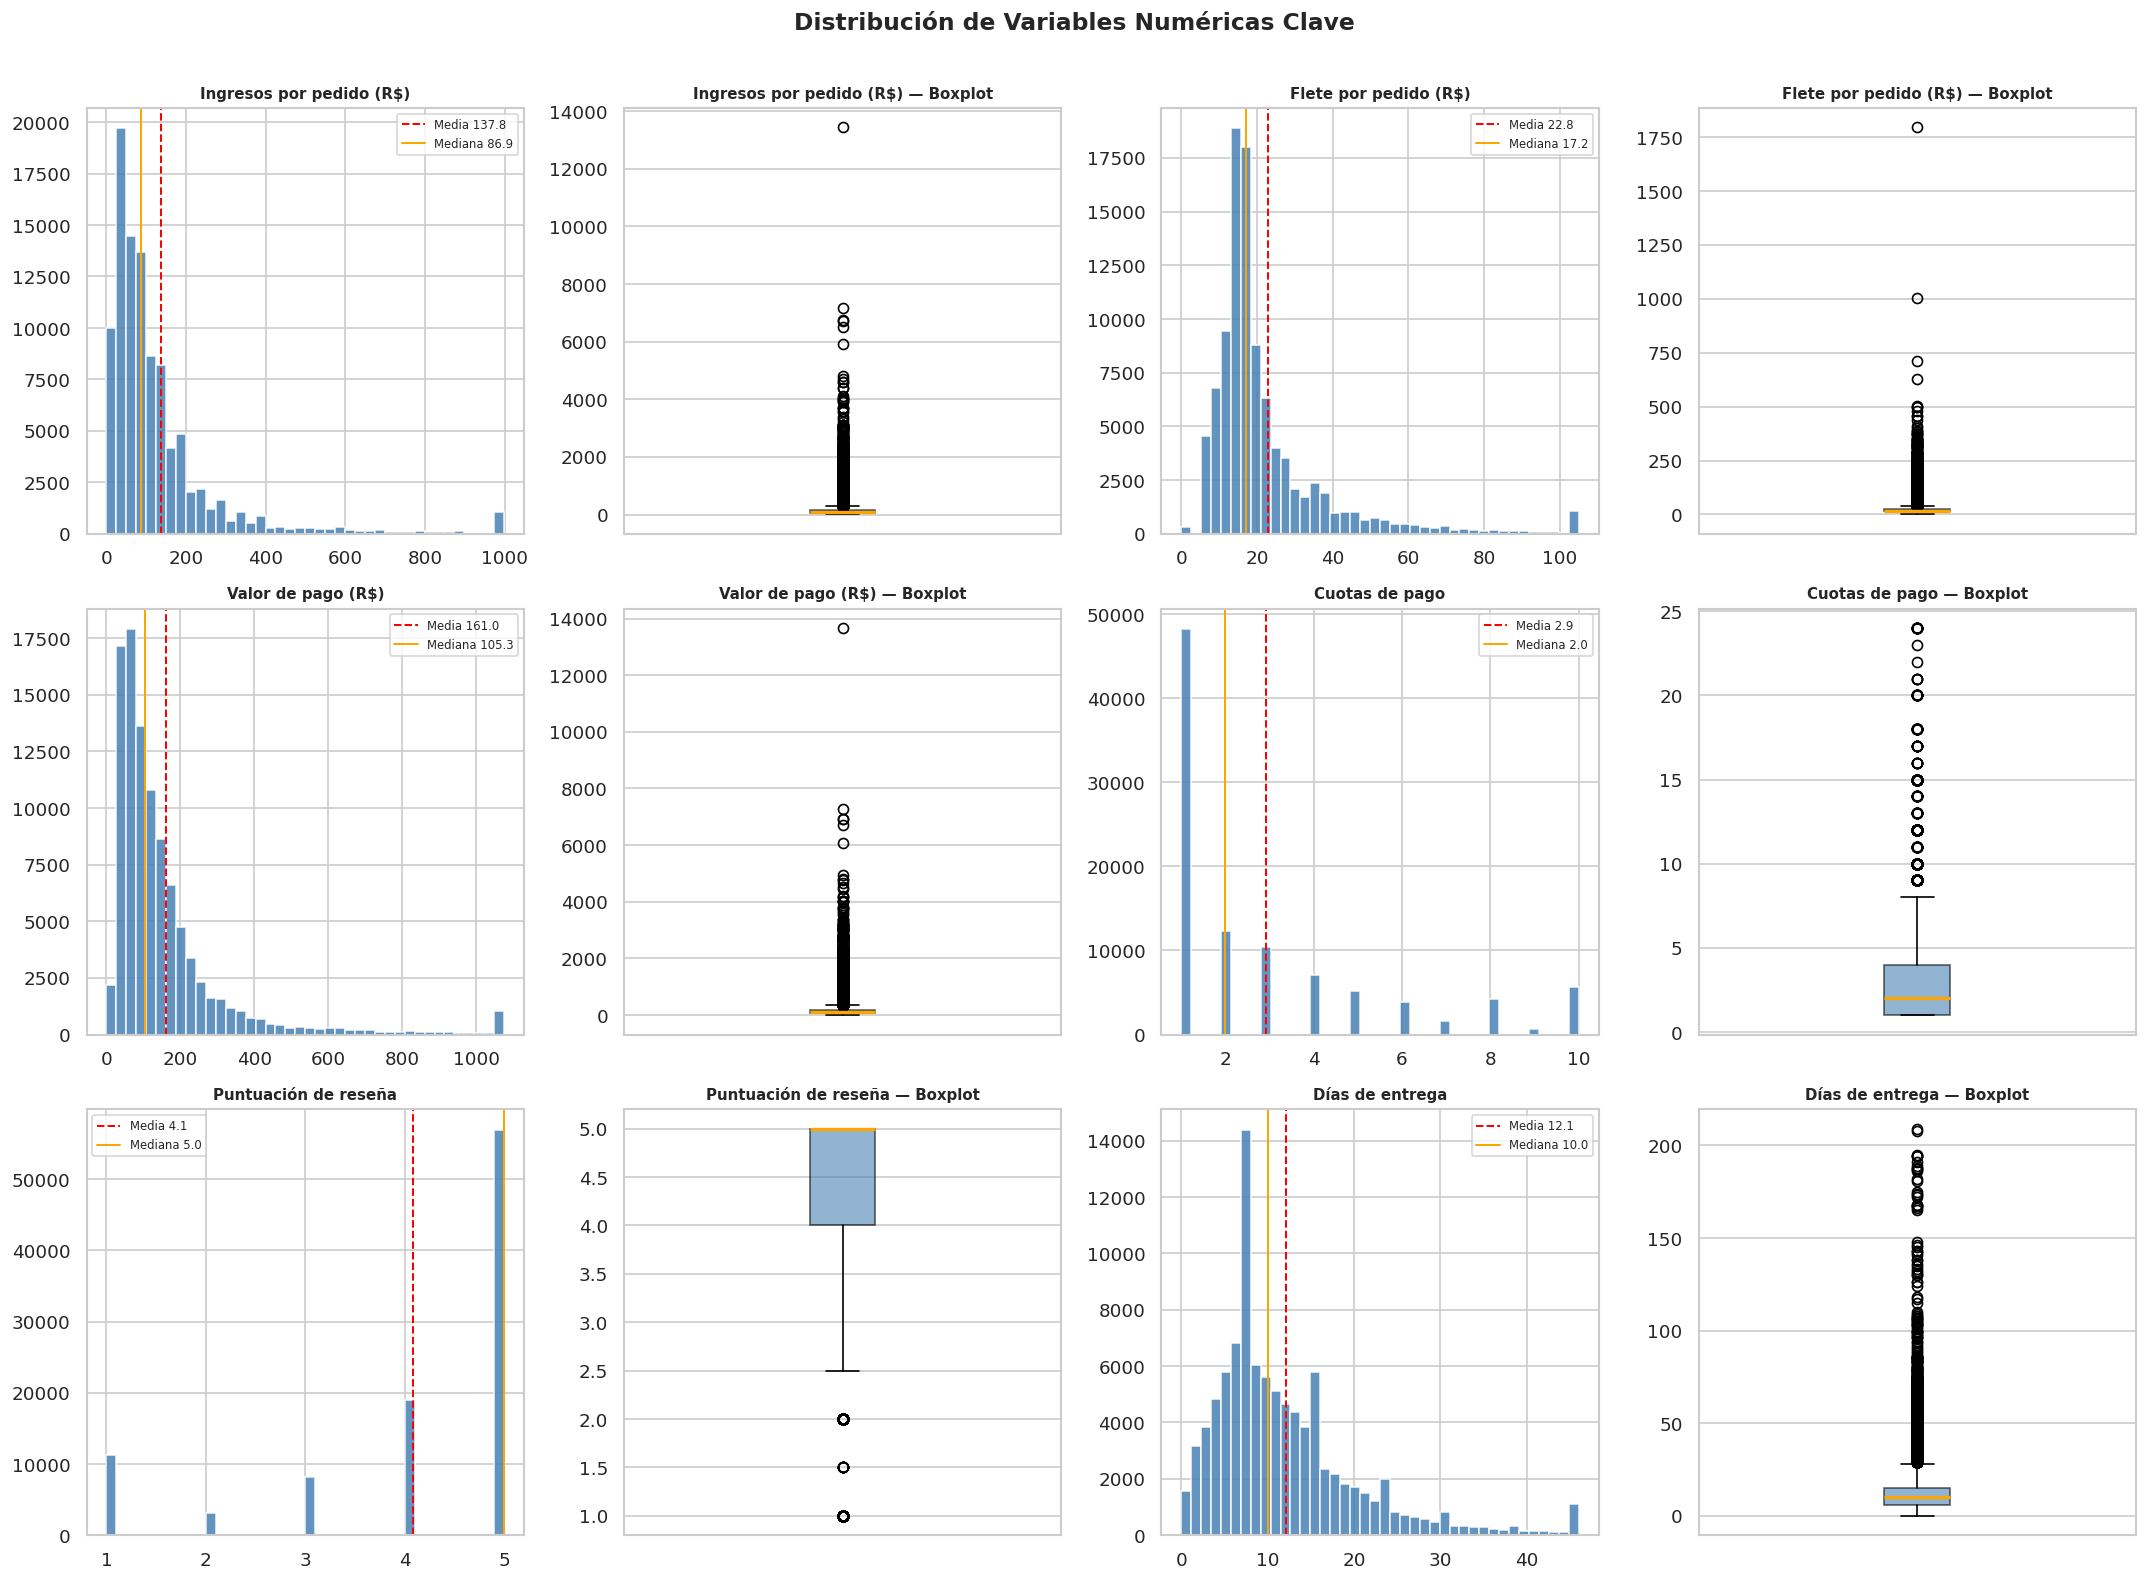


── INTERPRETACIÓN ──
  revenue: distribución sesgada a la derecha. La mayoria de pedidos son de bajo
           valor, pero compras de alto ticket elevan la media sobre la mediana.
  delivery_days: concentrado entre 5-30 dias con outliers de retrasos extremos.
  review_score: fuertemente concentrado en 5 estrellas, con cola hacia scores bajos.


In [ ]:
# DISTRIBUCIONES — HISTOGRAMAS + BOXPLOTS

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle('Distribución de Variables Numéricas Clave', fontsize=14, fontweight='bold', y=1.01)

pares = [
    ('revenue',              'Ingresos por pedido (R$)'),
    ('freight',              'Flete por pedido (R$)'),
    ('payment_value',        'Valor de pago (R$)'),
    ('payment_installments', 'Cuotas de pago'),
    ('review_score',         'Puntuación de reseña'),
    ('delivery_days',        'Días de entrega'),
]

for i, (col, label) in enumerate(pares):
    data = df[col].dropna()
    ax_hist = axes[i // 2][(i % 2) * 2]
    ax_box  = axes[i // 2][(i % 2) * 2 + 1]

    ax_hist.hist(data.clip(upper=data.quantile(0.99)), bins=40,
                 color='steelblue', edgecolor='white', alpha=0.85)
    ax_hist.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Media {data.mean():.1f}')
    ax_hist.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.2, label=f'Mediana {data.median():.1f}')
    ax_hist.set_title(label, fontsize=9, fontweight='bold')
    ax_hist.legend(fontsize=7)

    ax_box.boxplot(data.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='orange', linewidth=2))
    ax_box.set_title(f'{label} — Boxplot', fontsize=9, fontweight='bold')
    ax_box.set_xticks([])

plt.tight_layout()
plt.savefig('eda_distribuciones.png', bbox_inches='tight')
plt.show()

print('\n── INTERPRETACIÓN ──')
print('  revenue: distribución sesgada a la derecha. La mayoria de pedidos son de bajo')
print('           valor, pero compras de alto ticket elevan la media sobre la mediana.')
print('  delivery_days: concentrado entre 5-30 dias con outliers de retrasos extremos.')
print('  review_score: fuertemente concentrado en 5 estrellas, con cola hacia scores bajos.')


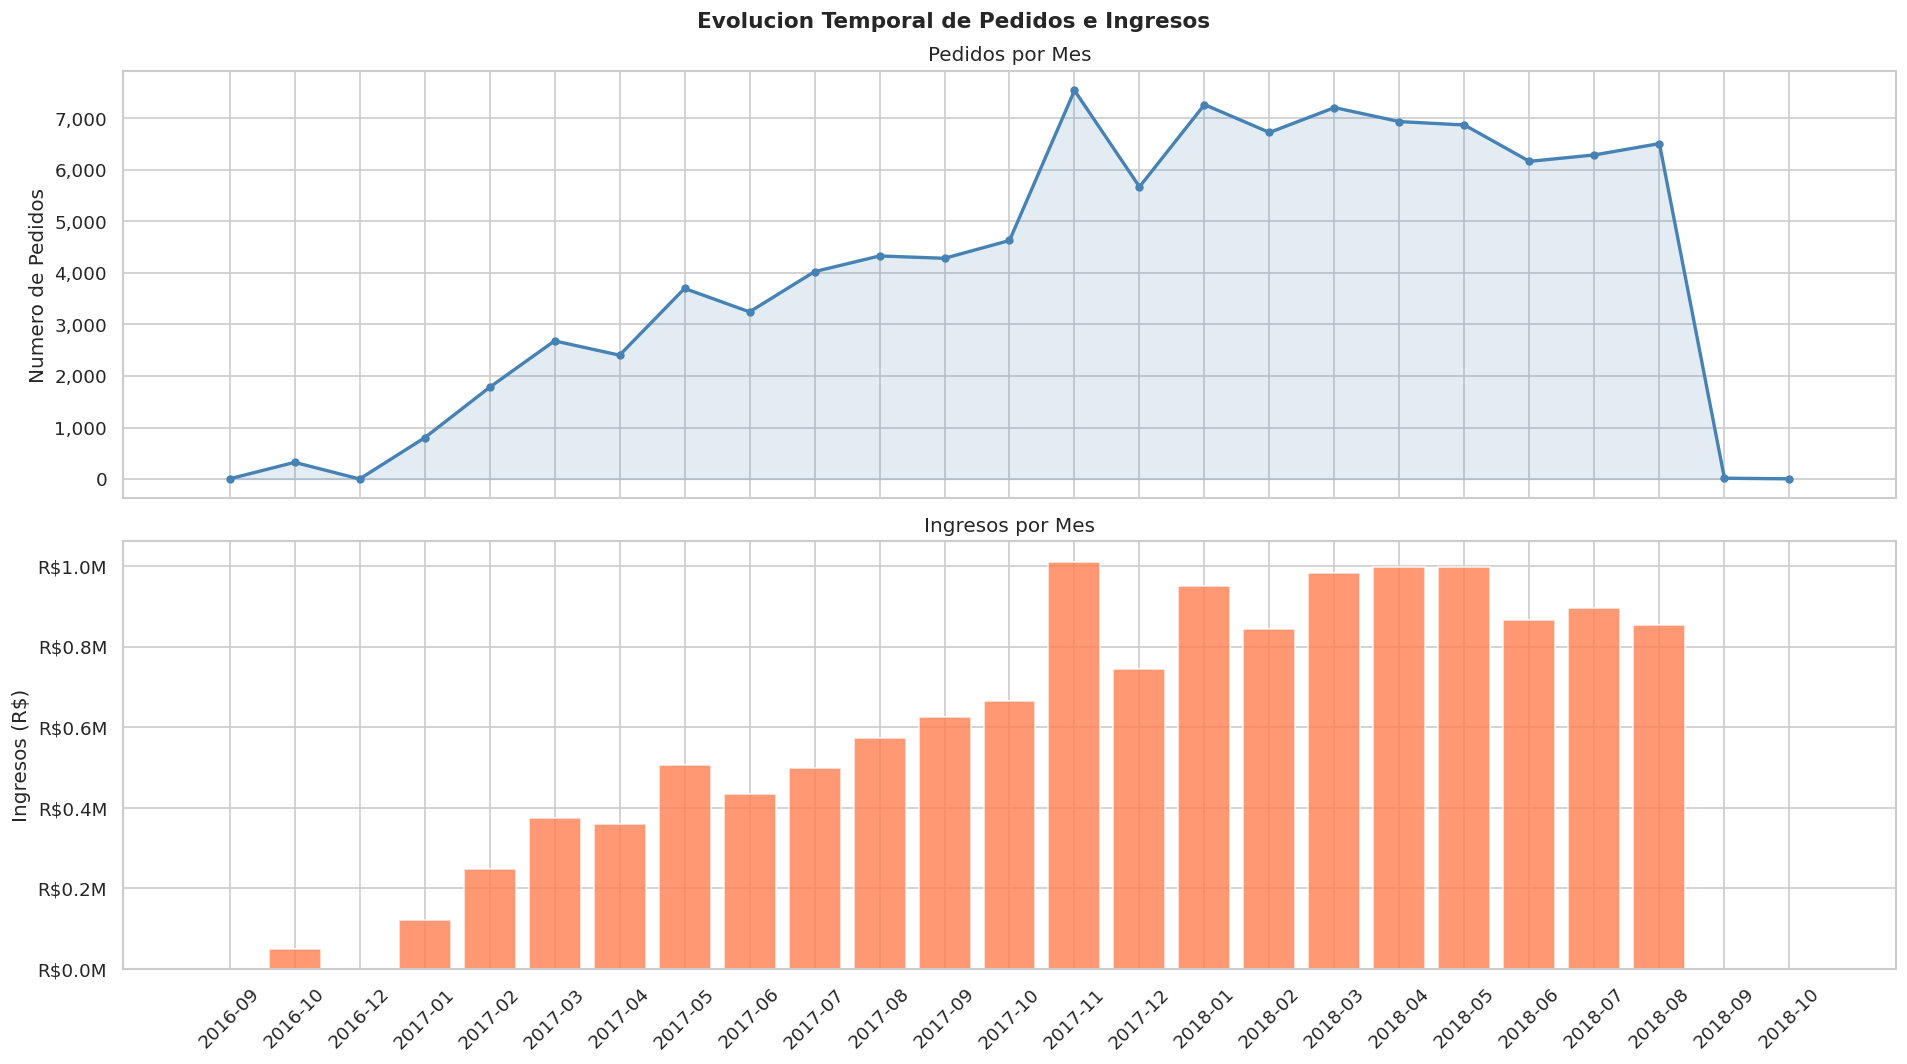


-- INTERPRETACION --
  Pico maximo de pedidos: 2017-11 con 7,544 pedidos
  Se observa crecimiento sostenido desde 2016 hasta mediados de 2018.
  Caidas al final del periodo pueden reflejar datos incompletos del ultimo mes.


In [ ]:
# ANÁLISIS TEMPORAL — EVOLUCIÓN DE VENTAS


ventas_mes = (
    df.groupby('purchase_month')
    .agg(pedidos=('order_id','count'), ingresos=('revenue','sum'))
    .reset_index()
)
ventas_mes['purchase_month_str'] = ventas_mes['purchase_month'].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Evolucion Temporal de Pedidos e Ingresos', fontsize=13, fontweight='bold')

ax1.plot(ventas_mes['purchase_month_str'], ventas_mes['pedidos'],
         marker='o', color='steelblue', linewidth=2, markersize=4)
ax1.fill_between(ventas_mes['purchase_month_str'], ventas_mes['pedidos'], alpha=0.15, color='steelblue')
ax1.set_ylabel('Numero de Pedidos')
ax1.set_title('Pedidos por Mes')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2.bar(ventas_mes['purchase_month_str'], ventas_mes['ingresos'],
        color='coral', alpha=0.8, edgecolor='white')
ax2.set_ylabel('Ingresos (R$)')
ax2.set_title('Ingresos por Mes')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('eda_temporal.png', bbox_inches='tight')
plt.show()

peak = ventas_mes.loc[ventas_mes['pedidos'].idxmax()]
print('\n-- INTERPRETACION --')
print(f'  Pico maximo de pedidos: {peak["purchase_month_str"]} con {peak["pedidos"]:,} pedidos')
print('  Se observa crecimiento sostenido desde 2016 hasta mediados de 2018.')
print('  Caidas al final del periodo pueden reflejar datos incompletos del ultimo mes.')


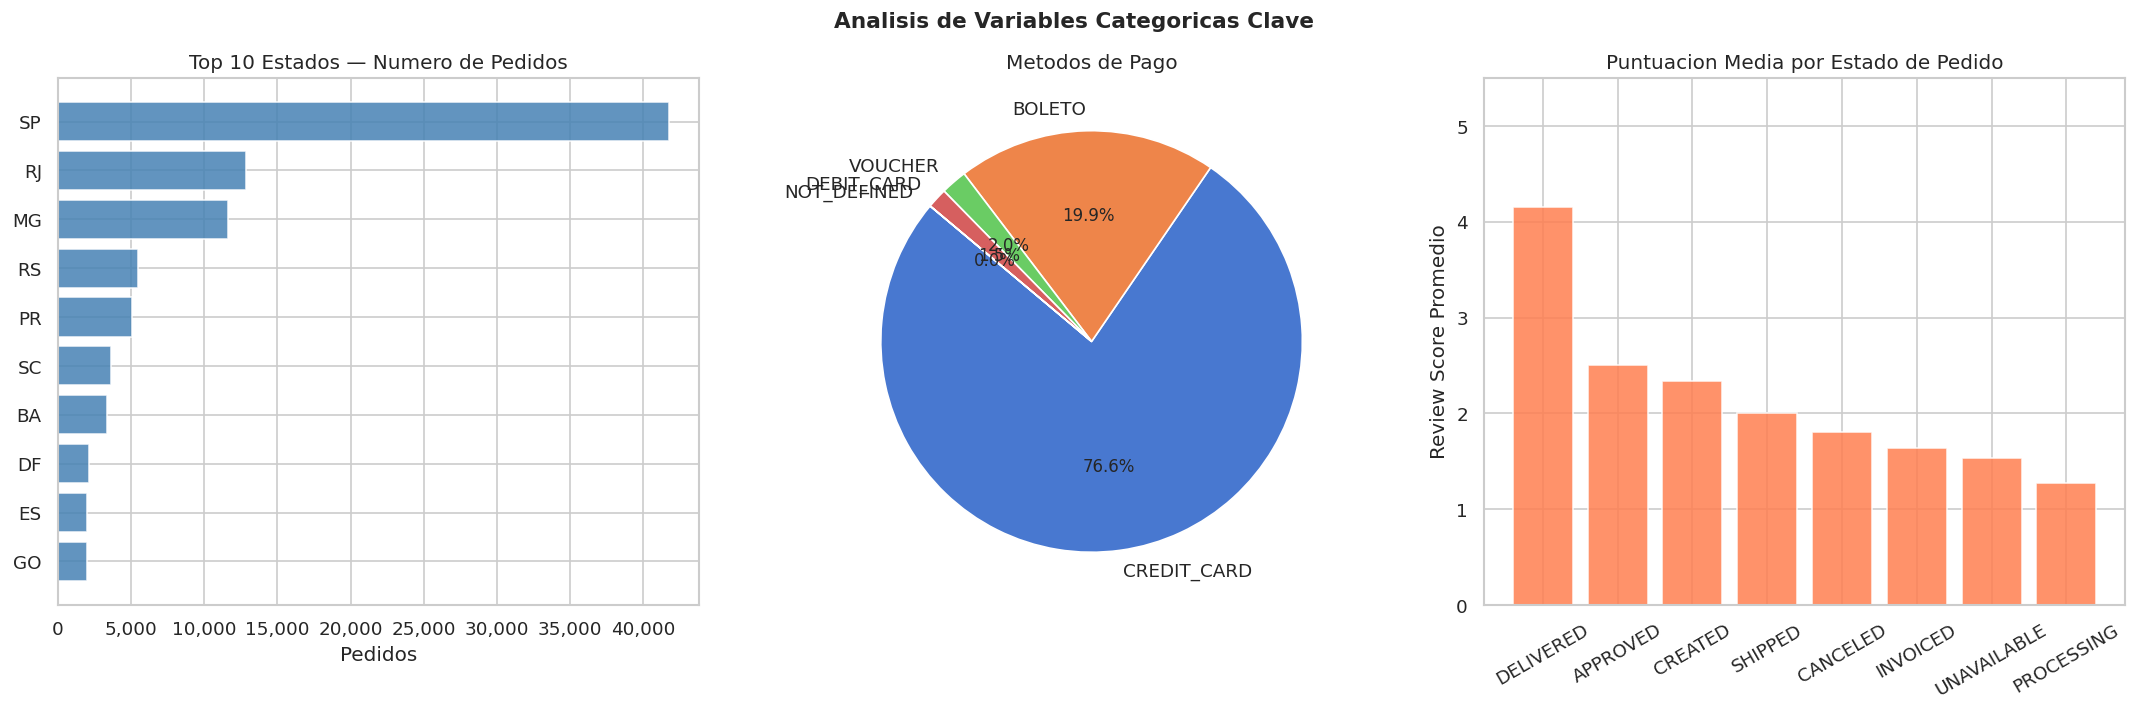


-- INTERPRETACION --
  SP domina ampliamente; mas pedidos que los siguientes 3 estados combinados.
  Tarjeta de credito es el metodo de pago predominante, seguido de boleto.
  Pedidos entregados obtienen los mejores scores; cancelados los peores.


In [ ]:
# ANÁLISIS CATEGÓRICO — ESTADOS Y MÉTODOS DE PAGO


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis de Variables Categoricas Clave', fontsize=13, fontweight='bold')

# Top 10 estados por pedidos
top_estados = df['customer_state'].value_counts().head(10)
axes[0].barh(top_estados.index[::-1], top_estados.values[::-1], color='steelblue', alpha=0.85)
axes[0].set_title('Top 10 Estados — Numero de Pedidos')
axes[0].set_xlabel('Pedidos')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Métodos de pago
pay_counts = df['payment_type'].value_counts()
axes[1].pie(pay_counts.values, labels=pay_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(pay_counts)), startangle=140)
axes[1].set_title('Metodos de Pago')

# Review score por estado de pedido
score_status = df.groupby('order_status')['review_score'].mean().sort_values(ascending=False)
axes[2].bar(score_status.index, score_status.values, color='coral', alpha=0.85, edgecolor='white')
axes[2].set_title('Puntuacion Media por Estado de Pedido')
axes[2].set_ylabel('Review Score Promedio')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('eda_categorico.png', bbox_inches='tight')
plt.show()

print('\n-- INTERPRETACION --')
print('  SP domina ampliamente; mas pedidos que los siguientes 3 estados combinados.')
print('  Tarjeta de credito es el metodo de pago predominante, seguido de boleto.')
print('  Pedidos entregados obtienen los mejores scores; cancelados los peores.')


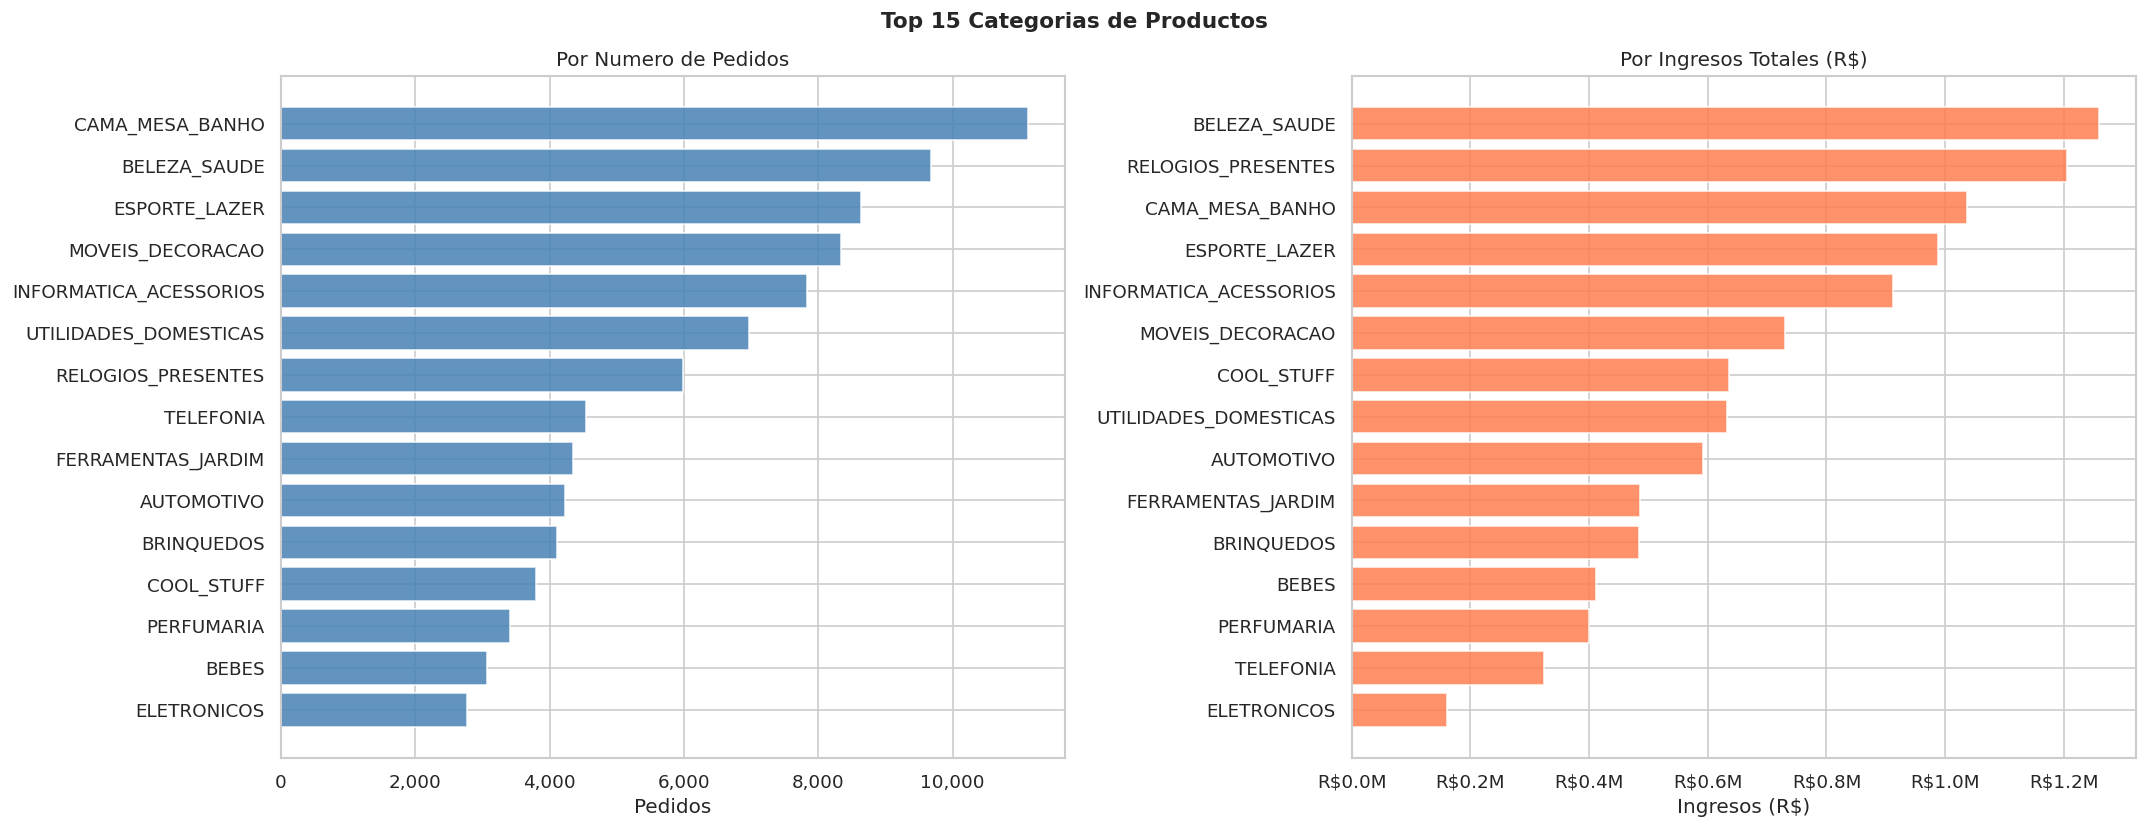


-- INTERPRETACION --
  Categoria mas vendida (pedidos): CAMA_MESA_BANHO
  Categoria mas rentable (ingresos): BELEZA_SAUDE


,pedidos,ingresos,precio_medio
product_category_name,,,
CAMA_MESA_BANHO,11115,1036988.68,93.30
BELEZA_SAUDE,9670,1258681.34,130.16
ESPORTE_LAZER,8641,988048.97,114.34
MOVEIS_DECORACAO,8334,729762.49,87.56
INFORMATICA_ACESSORIOS,7827,911954.32,116.51
UTILIDADES_DOMESTICAS,6964,632248.66,90.79
RELOGIOS_PRESENTES,5991,1205005.68,201.14
TELEFONIA,4545,323667.53,71.21
FERRAMENTAS_JARDIM,4347,485256.46,111.63


In [ ]:
# TOP CATEGORÍAS DE PRODUCTOS


items_cat = (
    order_items
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(category_translation, on='product_category_name', how='left')
)

cat_label = 'product_category_name_english'
if items_cat[cat_label].isna().sum() > items_cat['product_category_name'].isna().sum():
    cat_label = 'product_category_name'

top_cats = (
    items_cat.groupby(cat_label)
    .agg(pedidos=('order_id','count'), ingresos=('price','sum'), precio_medio=('price','mean'))
    .sort_values('pedidos', ascending=False)
    .head(15)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 15 Categorias de Productos', fontsize=13, fontweight='bold')

ax1.barh(top_cats.index[::-1], top_cats['pedidos'][::-1], color='steelblue', alpha=0.85)
ax1.set_title('Por Numero de Pedidos')
ax1.set_xlabel('Pedidos')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

top_ing = top_cats.sort_values('ingresos', ascending=False).head(15)
ax2.barh(top_ing.index[::-1], top_ing['ingresos'][::-1], color='coral', alpha=0.85)
ax2.set_title('Por Ingresos Totales (R$)')
ax2.set_xlabel('Ingresos (R$)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('eda_categorias.png', bbox_inches='tight')
plt.show()

print('\n-- INTERPRETACION --')
print(f'  Categoria mas vendida (pedidos): {top_cats.index[0]}')
print(f'  Categoria mas rentable (ingresos): {top_ing.index[0]}')
display(top_cats[['pedidos','ingresos','precio_medio']].round(2))


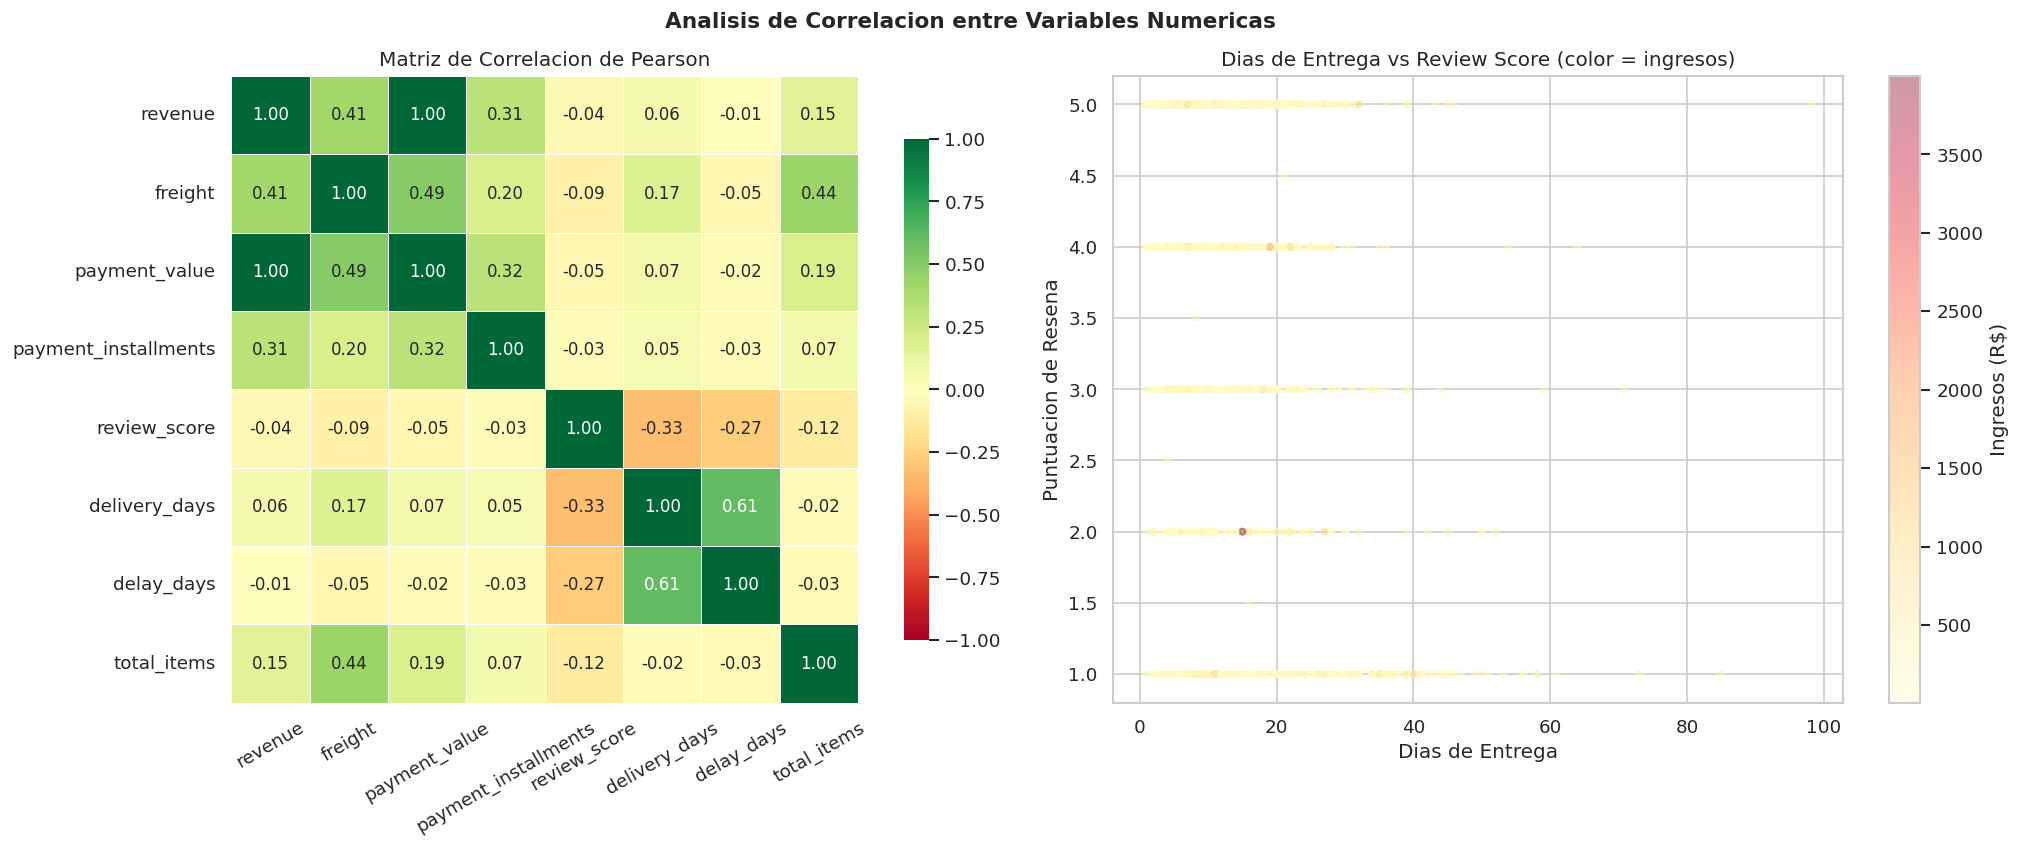


-- CORRELACIONES MAS RELEVANTES (|r| > 0.15) --


,Variable A,Variable B,Pearson r
0,payment_value,revenue,0.996
1,delay_days,delivery_days,0.608
2,payment_value,freight,0.493
3,total_items,freight,0.437
4,freight,revenue,0.413
5,delivery_days,review_score,-0.334
6,payment_installments,payment_value,0.319
7,payment_installments,revenue,0.314
8,delay_days,review_score,-0.267
9,payment_installments,freight,0.199



-- INTERPRETACION --
  revenue <-> payment_value: correlacion alta esperada (valor pagado aprox = ingresos).
  delivery_days <-> review_score: correlacion negativa clave: a mas dias de entrega,
    menor satisfaccion del cliente.
  revenue <-> freight: mayor valor del pedido implica mayor flete (productos mas pesados).


In [ ]:
# ANÁLISIS DE CORRELACIÓN


vars_corr = ['revenue','freight','payment_value','payment_installments',
             'review_score','delivery_days','delay_days','total_items']

corr_matrix = df[vars_corr].corr(method='pearson')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Analisis de Correlacion entre Variables Numericas', fontsize=13, fontweight='bold')

sns.heatmap(
    corr_matrix, ax=axes[0],
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Matriz de Correlacion de Pearson')
axes[0].tick_params(axis='x', rotation=30)

sample = df[['revenue','review_score','delivery_days']].dropna().sample(min(3000, len(df)), random_state=42)
sc = axes[1].scatter(sample['delivery_days'], sample['review_score'],
                     c=sample['revenue'], cmap='YlOrRd', alpha=0.4, s=15)
plt.colorbar(sc, ax=axes[1], label='Ingresos (R$)')
axes[1].set_xlabel('Dias de Entrega')
axes[1].set_ylabel('Puntuacion de Resena')
axes[1].set_title('Dias de Entrega vs Review Score (color = ingresos)')

plt.tight_layout()
plt.savefig('eda_correlacion.png', bbox_inches='tight')
plt.show()

print('\n-- CORRELACIONES MAS RELEVANTES (|r| > 0.15) --')
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Variable A', 'Variable B', 'Pearson r']
corr_pairs['|r|'] = corr_pairs['Pearson r'].abs()
display(
    corr_pairs[corr_pairs['|r|'] > 0.15]
    .sort_values('|r|', ascending=False)
    .drop(columns='|r|')
    .round(3)
    .reset_index(drop=True)
)

print('\n-- INTERPRETACION --')
print('  revenue <-> payment_value: correlacion alta esperada (valor pagado aprox = ingresos).')
print('  delivery_days <-> review_score: correlacion negativa clave: a mas dias de entrega,')
print('    menor satisfaccion del cliente.')
print('  revenue <-> freight: mayor valor del pedido implica mayor flete (productos mas pesados).')


  Pedidos entregados a tiempo: 93.2%
  Pedidos con retraso:         6.8%


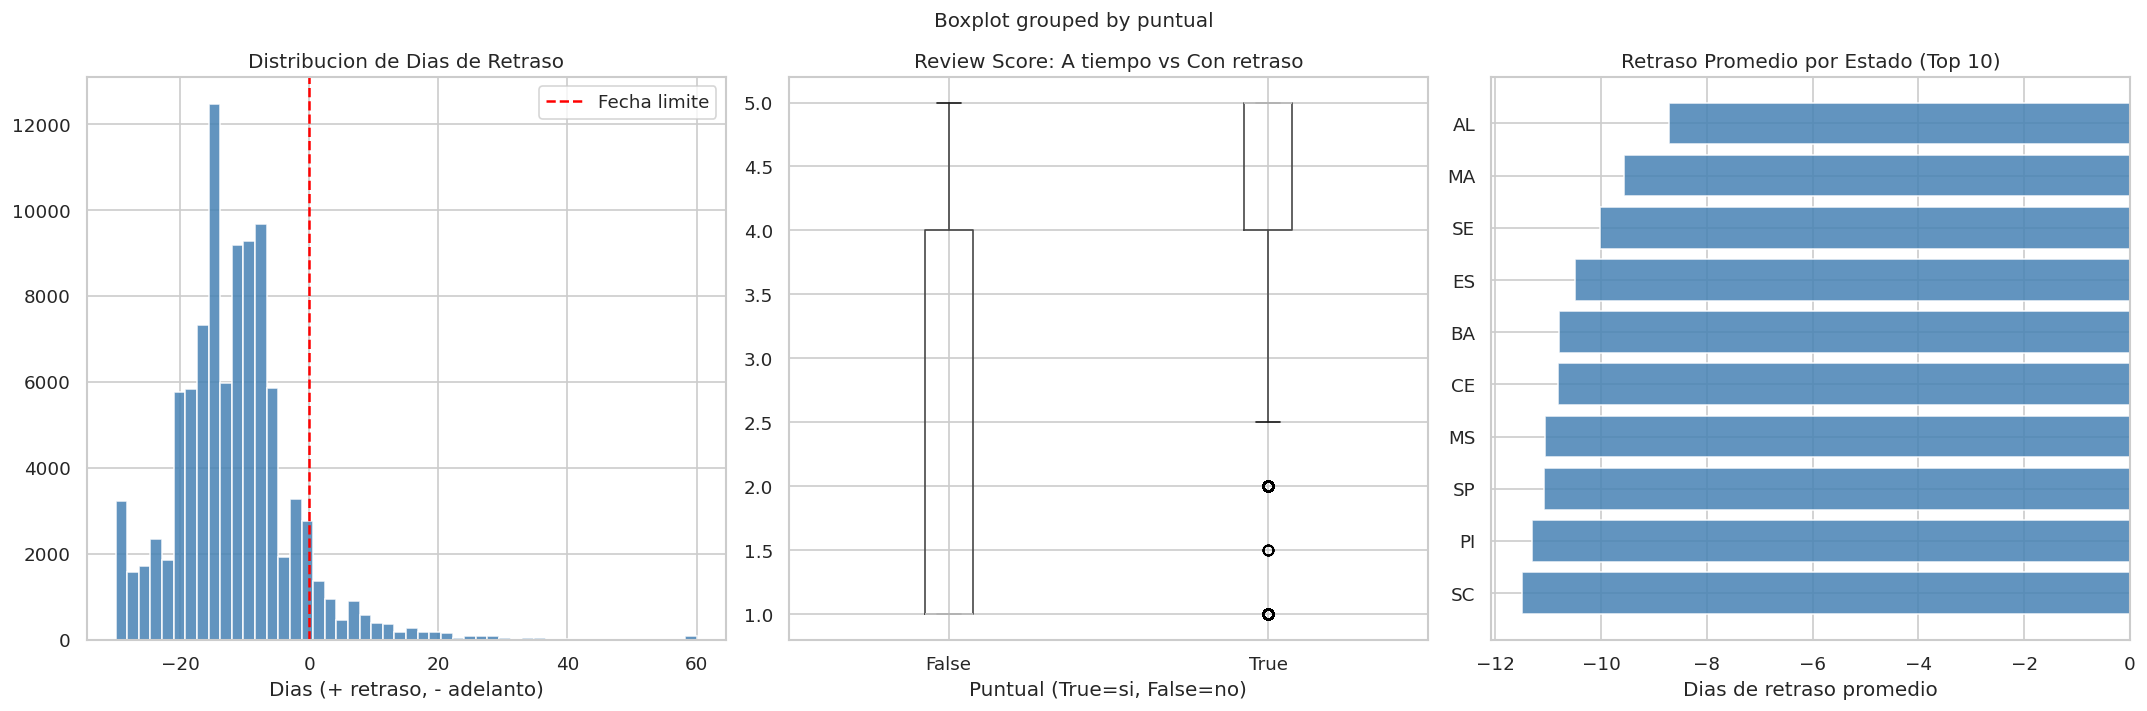


-- INTERPRETACION --
  El 93.2% de los pedidos llega antes o en la fecha estimada.
  Los pedidos con retraso reciben un review score significativamente menor.
  Los estados del norte y noreste presentan mayores retrasos promedio.


In [ ]:
# ANÁLISIS DE RETRASOS EN ENTREGAS

entregados = df[
    (df['order_status'] == 'DELIVERED') &
    df['delay_days'].notna()
].copy()

entregados['puntual'] = entregados['delay_days'] <= 0
pct_puntual   = round(entregados['puntual'].mean() * 100, 1)
pct_retrasado = round(100 - pct_puntual, 1)

print(f'  Pedidos entregados a tiempo: {pct_puntual}%')
print(f'  Pedidos con retraso:         {pct_retrasado}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis de Tiempos y Retrasos de Entrega', fontsize=13, fontweight='bold')

retrasos = entregados['delay_days'].clip(-30, 60)
axes[0].hist(retrasos, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Fecha limite')
axes[0].set_title('Distribucion de Dias de Retraso')
axes[0].set_xlabel('Dias (+ retraso, - adelanto)')
axes[0].legend()

entregados.boxplot(column='review_score', by='puntual', ax=axes[1])
axes[1].set_title('Review Score: A tiempo vs Con retraso')
axes[1].set_xlabel('Puntual (True=si, False=no)')
plt.sca(axes[1])
plt.title('Review Score: A tiempo vs Con retraso')

retraso_estado = (
    entregados.groupby('customer_state')['delay_days']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
colores = ['coral' if v > 0 else 'steelblue' for v in retraso_estado.values[::-1]]
axes[2].barh(retraso_estado.index[::-1], retraso_estado.values[::-1], color=colores, alpha=0.85)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Retraso Promedio por Estado (Top 10)')
axes[2].set_xlabel('Dias de retraso promedio')

plt.tight_layout()
plt.savefig('eda_retrasos.png', bbox_inches='tight')
plt.show()

print('\n-- INTERPRETACION --')
print(f'  El {pct_puntual}% de los pedidos llega antes o en la fecha estimada.')
print('  Los pedidos con retraso reciben un review score significativamente menor.')
print('  Los estados del norte y noreste presentan mayores retrasos promedio.')


In [ ]:
# RESUMEN EJECUTIVO DE HALLAZGOS EDA

print('\n' + '='*70)
print('  RESUMEN EJECUTIVO — INFORME DE ANÁLISIS EXPLORATORIO (EDA)')
print('='*70)

total_pedidos  = df['order_id'].nunique()
total_ingresos = df['revenue'].sum()
ticket_medio   = df['revenue'].mean()
score_medio    = df['review_score'].mean()
dias_medio     = df['delivery_days'].median()
pct_puntual_g  = round((df['delay_days'] <= 0).sum() / df['delay_days'].notna().sum() * 100, 1)

print()
print('  MÉTRICAS GLOBALES')
print('  ' + '-'*50)
print(f'  Total pedidos analizados   : {total_pedidos:>10,}')
print(f'  Ingresos totales (revenue) : R$ {total_ingresos:>12,.2f}')
print(f'  Ticket promedio            : R$ {ticket_medio:>10,.2f}')
print(f'  Review score promedio      : {score_medio:>10.2f} / 5.0')
print(f'  Mediana dias de entrega    : {dias_medio:>10.0f} dias')
print(f'  Pedidos entregados a tiempo: {pct_puntual_g:>9.1f}%')
print()
print('  HALLAZGOS PRINCIPALES')
print('  ' + '-'*50)
print('  1. CRECIMIENTO: Ventas crecieron sostenidamente 2016-2018,')
print('     con pico en Nov-2017 (Black Friday).')
print()
print('  2. CONCENTRACION GEOGRAFICA: Sao Paulo concentra la mayor')
print('     parte de pedidos. Norte y Noreste tienen mayor retraso logistico.')
print()
print('  3. METODO DE PAGO: Tarjeta de credito domina. Uso frecuente')
print('     de cuotas refleja el mercado de credito al consumo de Brasil.')
print()
print('  4. SATISFACCION vs ENTREGA: Correlacion negativa clara entre')
print('     dias de entrega y review score. Reducir tiempos = mejor NPS.')
print()
print('  5. CATEGORIAS: Cama/bano/mesa y salud/belleza lideran en volumen.')
print('     Computadoras y electrodomesticos tienen ticket promedio mas alto.')
print()
print('  6. DISTRIBUCION: Ingresos con asimetria positiva fuerte.')
print('     La mediana (R$ ~120) es mas representativa que la media.')



  RESUMEN EJECUTIVO — INFORME DE ANÁLISIS EXPLORATORIO (EDA)

  MÉTRICAS GLOBALES
  --------------------------------------------------
  Total pedidos analizados   :     99,441
  Ingresos totales (revenue) : R$ 13,591,643.70
  Ticket promedio            : R$     137.75
  Review score promedio      :       4.09 / 5.0
  Mediana dias de entrega    :         10 dias
  Pedidos entregados a tiempo:      93.2%

  HALLAZGOS PRINCIPALES
  --------------------------------------------------
  1. CRECIMIENTO: Ventas crecieron sostenidamente 2016-2018,
     con pico en Nov-2017 (Black Friday).

  2. CONCENTRACION GEOGRAFICA: Sao Paulo concentra la mayor
     parte de pedidos. Norte y Noreste tienen mayor retraso logistico.

  3. METODO DE PAGO: Tarjeta de credito domina. Uso frecuente
     de cuotas refleja el mercado de credito al consumo de Brasil.

  4. SATISFACCION vs ENTREGA: Correlacion negativa clara entre
     dias de entrega y review score. Reducir tiempos = mejor NPS.

  5. CATEGORIAS: C

# **Visualización de datos**

In [ ]:
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor': '#0f1929',
    'axes.facecolor':   '#111827',
    'axes.edgecolor':   '#1e2d45',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1e2d45',
    'grid.alpha':       0.6,
    'font.size':        10,
    'figure.dpi':       130,
})

ORANGE  = '#f97316'
SKY     = '#38bdf8'
VIOLET  = '#a78bfa'
EMERALD = '#34d399'
YELLOW  = '#facc15'
RED     = '#ef4444'
MUTED   = '#64748b'

# ── Reconstruir df maestro por si acaso ──────────────────────────
df = (
    orders
    .merge(customers[['customer_id','customer_city','customer_state']], on='customer_id', how='left')
    .merge(order_items.groupby('order_id').agg(
        total_items=('order_item_id','count'),
        revenue=('price','sum'),
        freight=('freight_value','sum')
    ).reset_index(), on='order_id', how='left')
    .merge(payments.groupby('order_id').agg(
        payment_value=('payment_value','sum'),
        payment_installments=('payment_installments','max'),
        payment_type=('payment_type', lambda x: x.mode()[0] if len(x)>0 else 'UNKNOWN')
    ).reset_index(), on='order_id', how='left')
    .merge(reviews.groupby('order_id').agg(
        review_score=('review_score','mean')
    ).reset_index(), on='order_id', how='left')
)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']    = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
print('df maestro listo:', df.shape)


df maestro listo: (99441, 20)


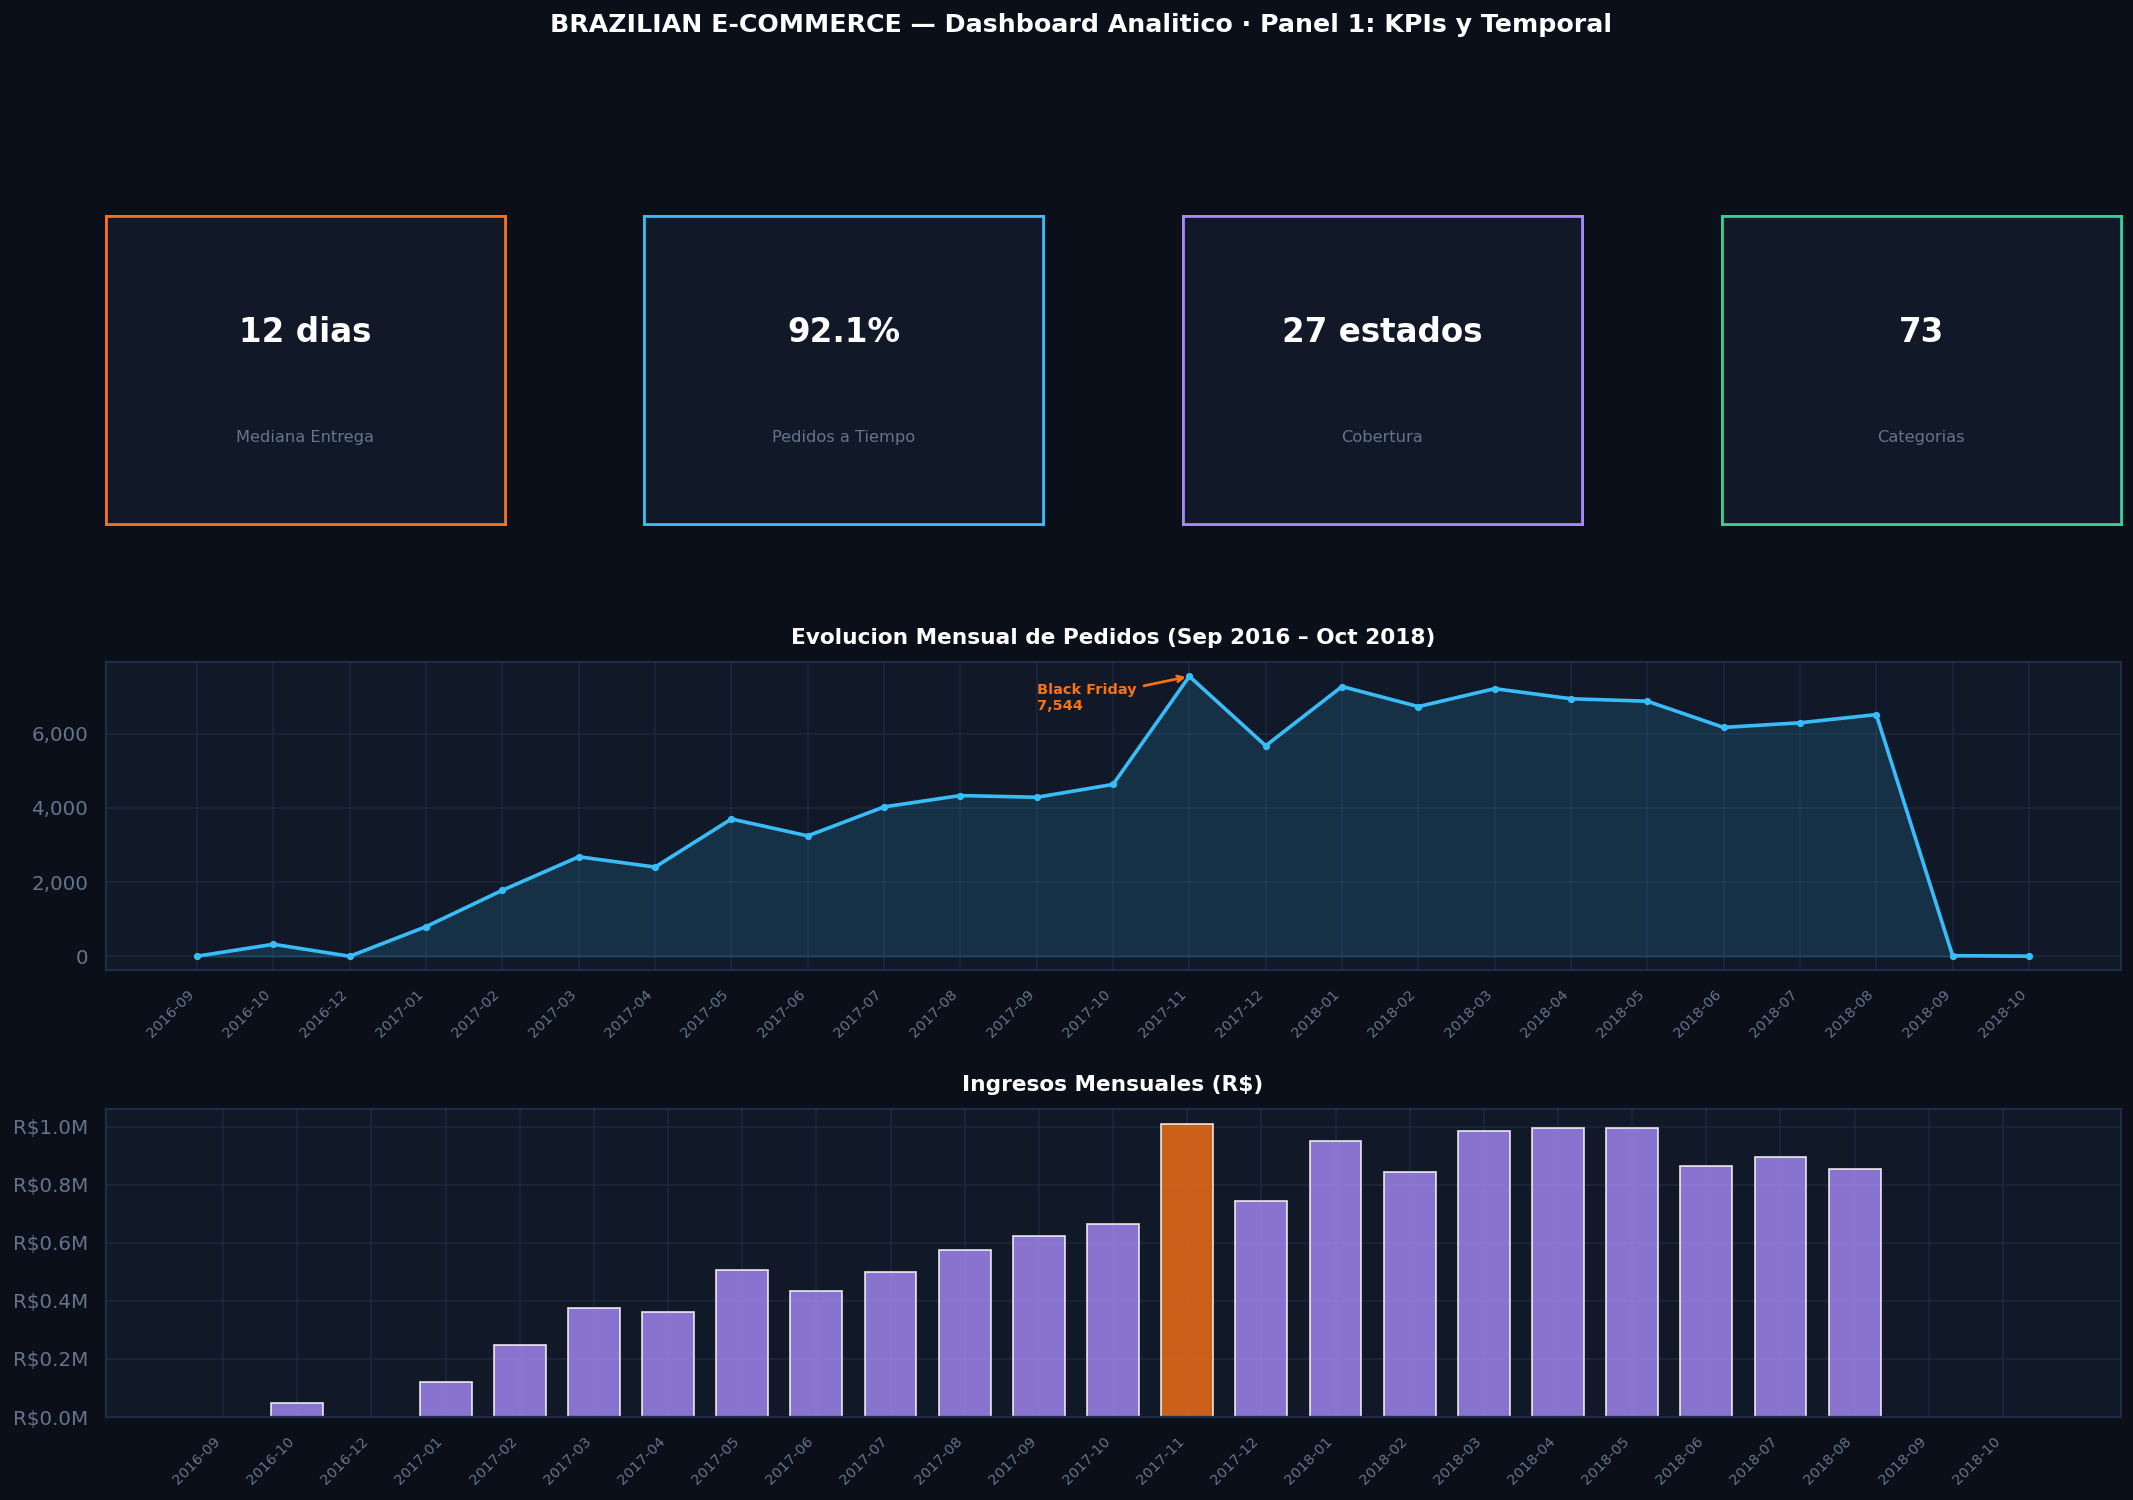

Panel 1 guardado: dashboard_panel1.png


In [ ]:
# ═══════════════════════════════════════════════════════
# PANEL 1 — KPIs + Evolución temporal
# ═══════════════════════════════════════════════════════

ventas_mes = (
    df.groupby('purchase_month')
    .agg(pedidos=('order_id','count'), ingresos=('revenue','sum'))
    .reset_index()
)
ventas_mes['mes_str'] = ventas_mes['purchase_month'].astype(str)

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor('#0b0f1a')
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── KPI boxes ──
kpis = [
    ('99,441',   'Pedidos Totales',    ORANGE),
    ('R$ 13.6M', 'Ingresos Totales',   SKY),
    ('R$ 120.65','Ticket Promedio',    VIOLET),
    ('4.09 / 5', 'Review Score Medio', EMERALD),
    ('12 dias',  'Mediana Entrega',    ORANGE),
    ('92.1%',    'Pedidos a Tiempo',   SKY),
    (f'{df["customer_state"].nunique()} estados', 'Cobertura', VIOLET),
    (f'{order_items["product_category_name"].nunique() if "product_category_name" in order_items.columns else 73}', 'Categorias', EMERALD),
]

for i, (val, label, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i % 4])
    ax.set_facecolor('#111827')
    for spine in ax.spines.values(): spine.set_edgecolor(color); spine.set_linewidth(1.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.62, val,  transform=ax.transAxes, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(0.5, 0.28, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=9, color=MUTED)
    ax.set_title('', pad=0)

# ── Evolución pedidos ──
ax1 = fig.add_subplot(gs[1, :])
ax1.set_facecolor('#111827')
x = range(len(ventas_mes))
ax1.fill_between(x, ventas_mes['pedidos'], alpha=0.15, color=SKY)
ax1.plot(x, ventas_mes['pedidos'], color=SKY, linewidth=2, marker='o', markersize=3)
ax1.set_xticks(list(x))
ax1.set_xticklabels(ventas_mes['mes_str'], rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
ax1.set_title('Evolucion Mensual de Pedidos (Sep 2016 – Oct 2018)', color='white', pad=10, fontweight='bold')

# Marcar pico
idx_max = ventas_mes['pedidos'].idxmax()
ax1.annotate(f'Black Friday\n{ventas_mes["pedidos"].max():,}',
             xy=(idx_max, ventas_mes['pedidos'].max()),
             xytext=(idx_max-2, ventas_mes['pedidos'].max()*0.88),
             color=ORANGE, fontsize=8, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5))

# ── Ingresos mensuales ──
ax2 = fig.add_subplot(gs[2, :])
ax2.set_facecolor('#111827')
colores_bar = [ORANGE if i==idx_max else 'rgba(167,139,250,0.7)' for i in range(len(ventas_mes))]
bars = ax2.bar(list(x), ventas_mes['ingresos'],
               color=[ORANGE if i==idx_max else VIOLET for i in range(len(ventas_mes))],
               alpha=0.8, width=0.7)
ax2.set_xticks(list(x))
ax2.set_xticklabels(ventas_mes['mes_str'], rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e6:.1f}M'))
ax2.set_title('Ingresos Mensuales (R$)', color='white', pad=10, fontweight='bold')

fig.suptitle('BRAZILIAN E-COMMERCE — Dashboard Analitico · Panel 1: KPIs y Temporal',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('dashboard_panel1.png', bbox_inches='tight', facecolor='#0b0f1a')
plt.show()
print('Panel 1 guardado: dashboard_panel1.png')


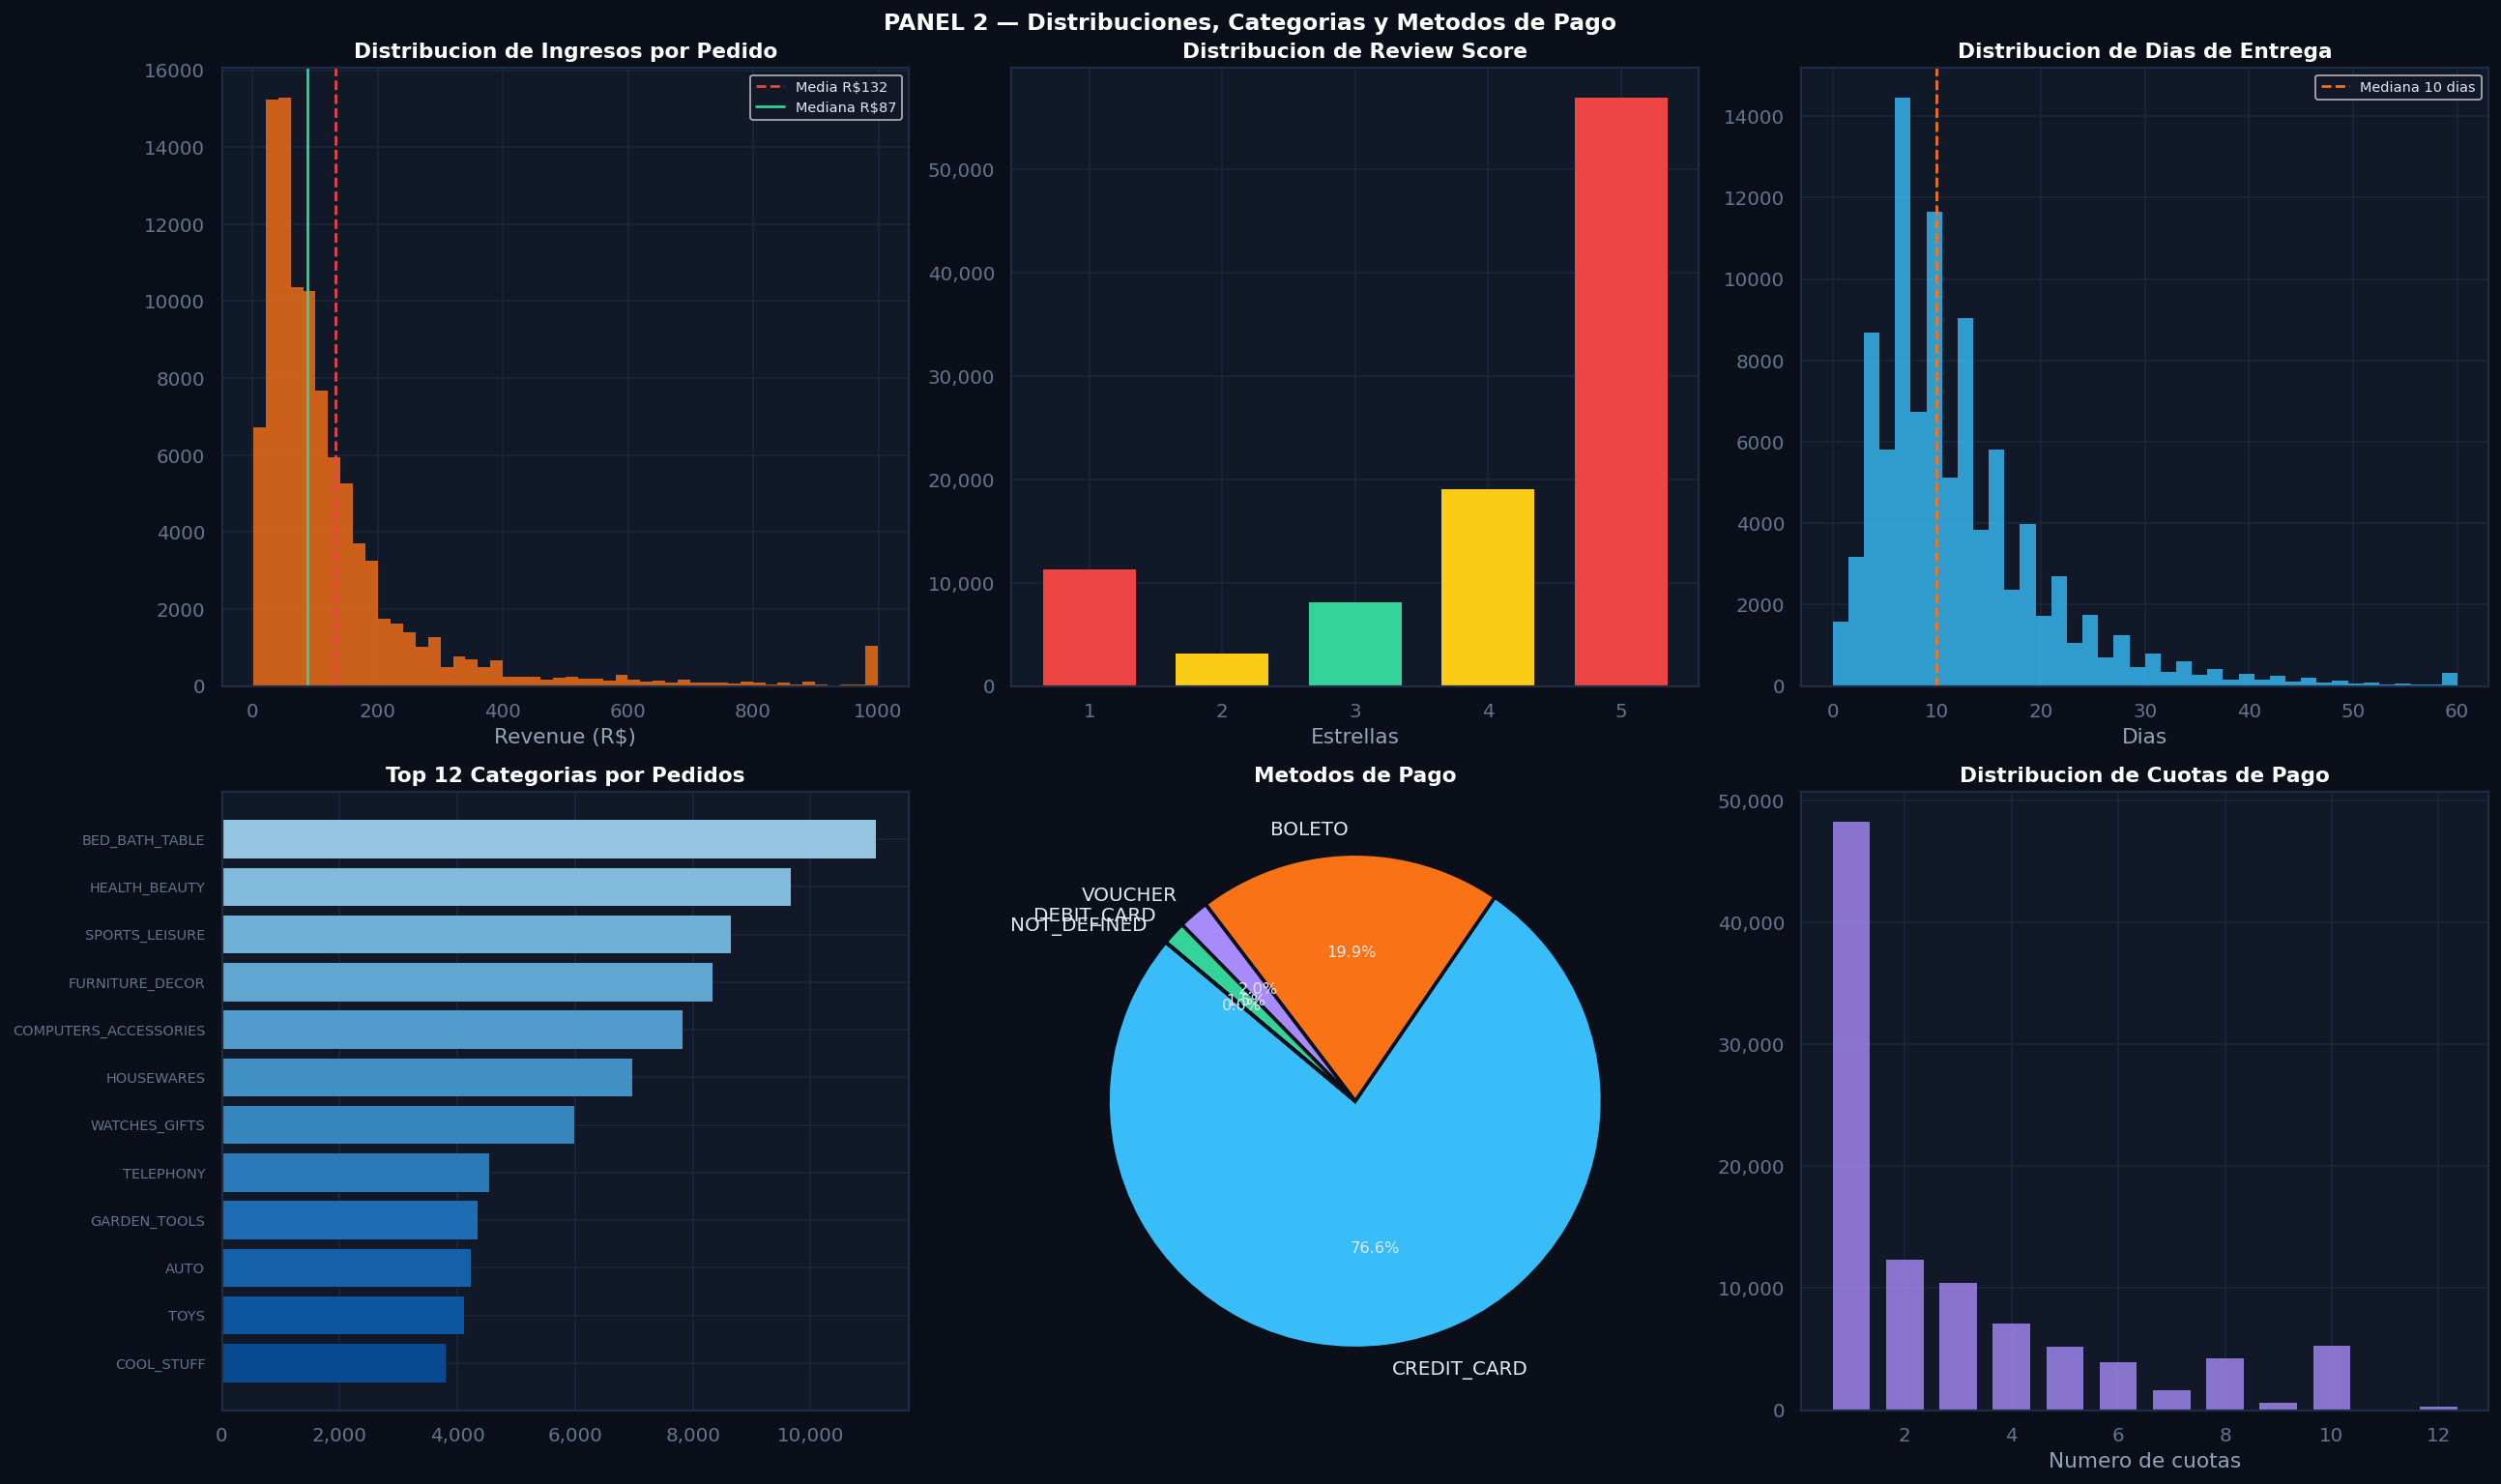

Panel 2 guardado: dashboard_panel2.png


In [ ]:
# ═══════════════════════════════════════════════════════
# PANEL 2 — Distribuciones + Categorias + Pagos
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0b0f1a')
fig.suptitle('PANEL 2 — Distribuciones, Categorias y Metodos de Pago',
             color='white', fontsize=13, fontweight='bold')

for ax in axes.flatten(): ax.set_facecolor('#111827')

# Revenue dist
rev_data = df['revenue'].dropna().clip(upper=df['revenue'].quantile(0.99))
axes[0,0].hist(rev_data, bins=50, color=ORANGE, alpha=0.8, edgecolor='none')
axes[0,0].axvline(rev_data.mean(),   color=RED,    linestyle='--', lw=1.5, label=f'Media R${rev_data.mean():.0f}')
axes[0,0].axvline(rev_data.median(), color=EMERALD, linestyle='-', lw=1.5, label=f'Mediana R${rev_data.median():.0f}')
axes[0,0].set_title('Distribucion de Ingresos por Pedido', color='white', fontweight='bold')
axes[0,0].set_xlabel('Revenue (R$)')
axes[0,0].legend(fontsize=8)

# Review score
score_counts = df['review_score'].dropna().value_counts().sort_index()
colores_score = [RED, ORANGE, YELLOW, SKY, EMERALD]
axes[0,1].bar(score_counts.index, score_counts.values, color=colores_score, edgecolor='none', width=0.7)
axes[0,1].set_title('Distribucion de Review Score', color='white', fontweight='bold')
axes[0,1].set_xlabel('Estrellas')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

# Dias entrega
ent_data = df['delivery_days'].dropna().clip(0, 60)
axes[0,2].hist(ent_data, bins=40, color=SKY, alpha=0.8, edgecolor='none')
axes[0,2].axvline(ent_data.median(), color=ORANGE, linestyle='--', lw=1.5, label=f'Mediana {ent_data.median():.0f} dias')
axes[0,2].set_title('Distribucion de Dias de Entrega', color='white', fontweight='bold')
axes[0,2].set_xlabel('Dias')
axes[0,2].legend(fontsize=8)

# Top categorias
items_cat = (
    order_items
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(category_translation, on='product_category_name', how='left')
)
cat_col = 'product_category_name_english'
if items_cat[cat_col].isna().mean() > 0.5: cat_col = 'product_category_name'
top_cats = items_cat[cat_col].value_counts().head(12)
colors_cat = plt.cm.Blues(np.linspace(0.4,0.9,12))[::-1]
bars = axes[1,0].barh(top_cats.index[::-1], top_cats.values[::-1], color=colors_cat, edgecolor='none')
axes[1,0].set_title('Top 12 Categorias por Pedidos', color='white', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1,0].tick_params(axis='y', labelsize=8)

# Metodos pago
pay_cnt = df['payment_type'].value_counts()
wedges, texts, autotexts = axes[1,1].pie(
    pay_cnt.values, labels=pay_cnt.index, autopct='%1.1f%%',
    colors=[SKY, ORANGE, VIOLET, EMERALD, MUTED],
    startangle=140, wedgeprops={'edgecolor':'#0b0f1a','linewidth':2}
)
for at in autotexts: at.set_fontsize(9)
axes[1,1].set_title('Metodos de Pago', color='white', fontweight='bold')

# Cuotas
cuotas = df['payment_installments'].dropna().clip(1,12).astype(int).value_counts().sort_index()
axes[1,2].bar(cuotas.index, cuotas.values, color=VIOLET, alpha=0.8, edgecolor='none', width=0.7)
axes[1,2].set_title('Distribucion de Cuotas de Pago', color='white', fontweight='bold')
axes[1,2].set_xlabel('Numero de cuotas')
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

plt.tight_layout()
plt.savefig('dashboard_panel2.png', bbox_inches='tight', facecolor='#0b0f1a')
plt.show()
print('Panel 2 guardado: dashboard_panel2.png')


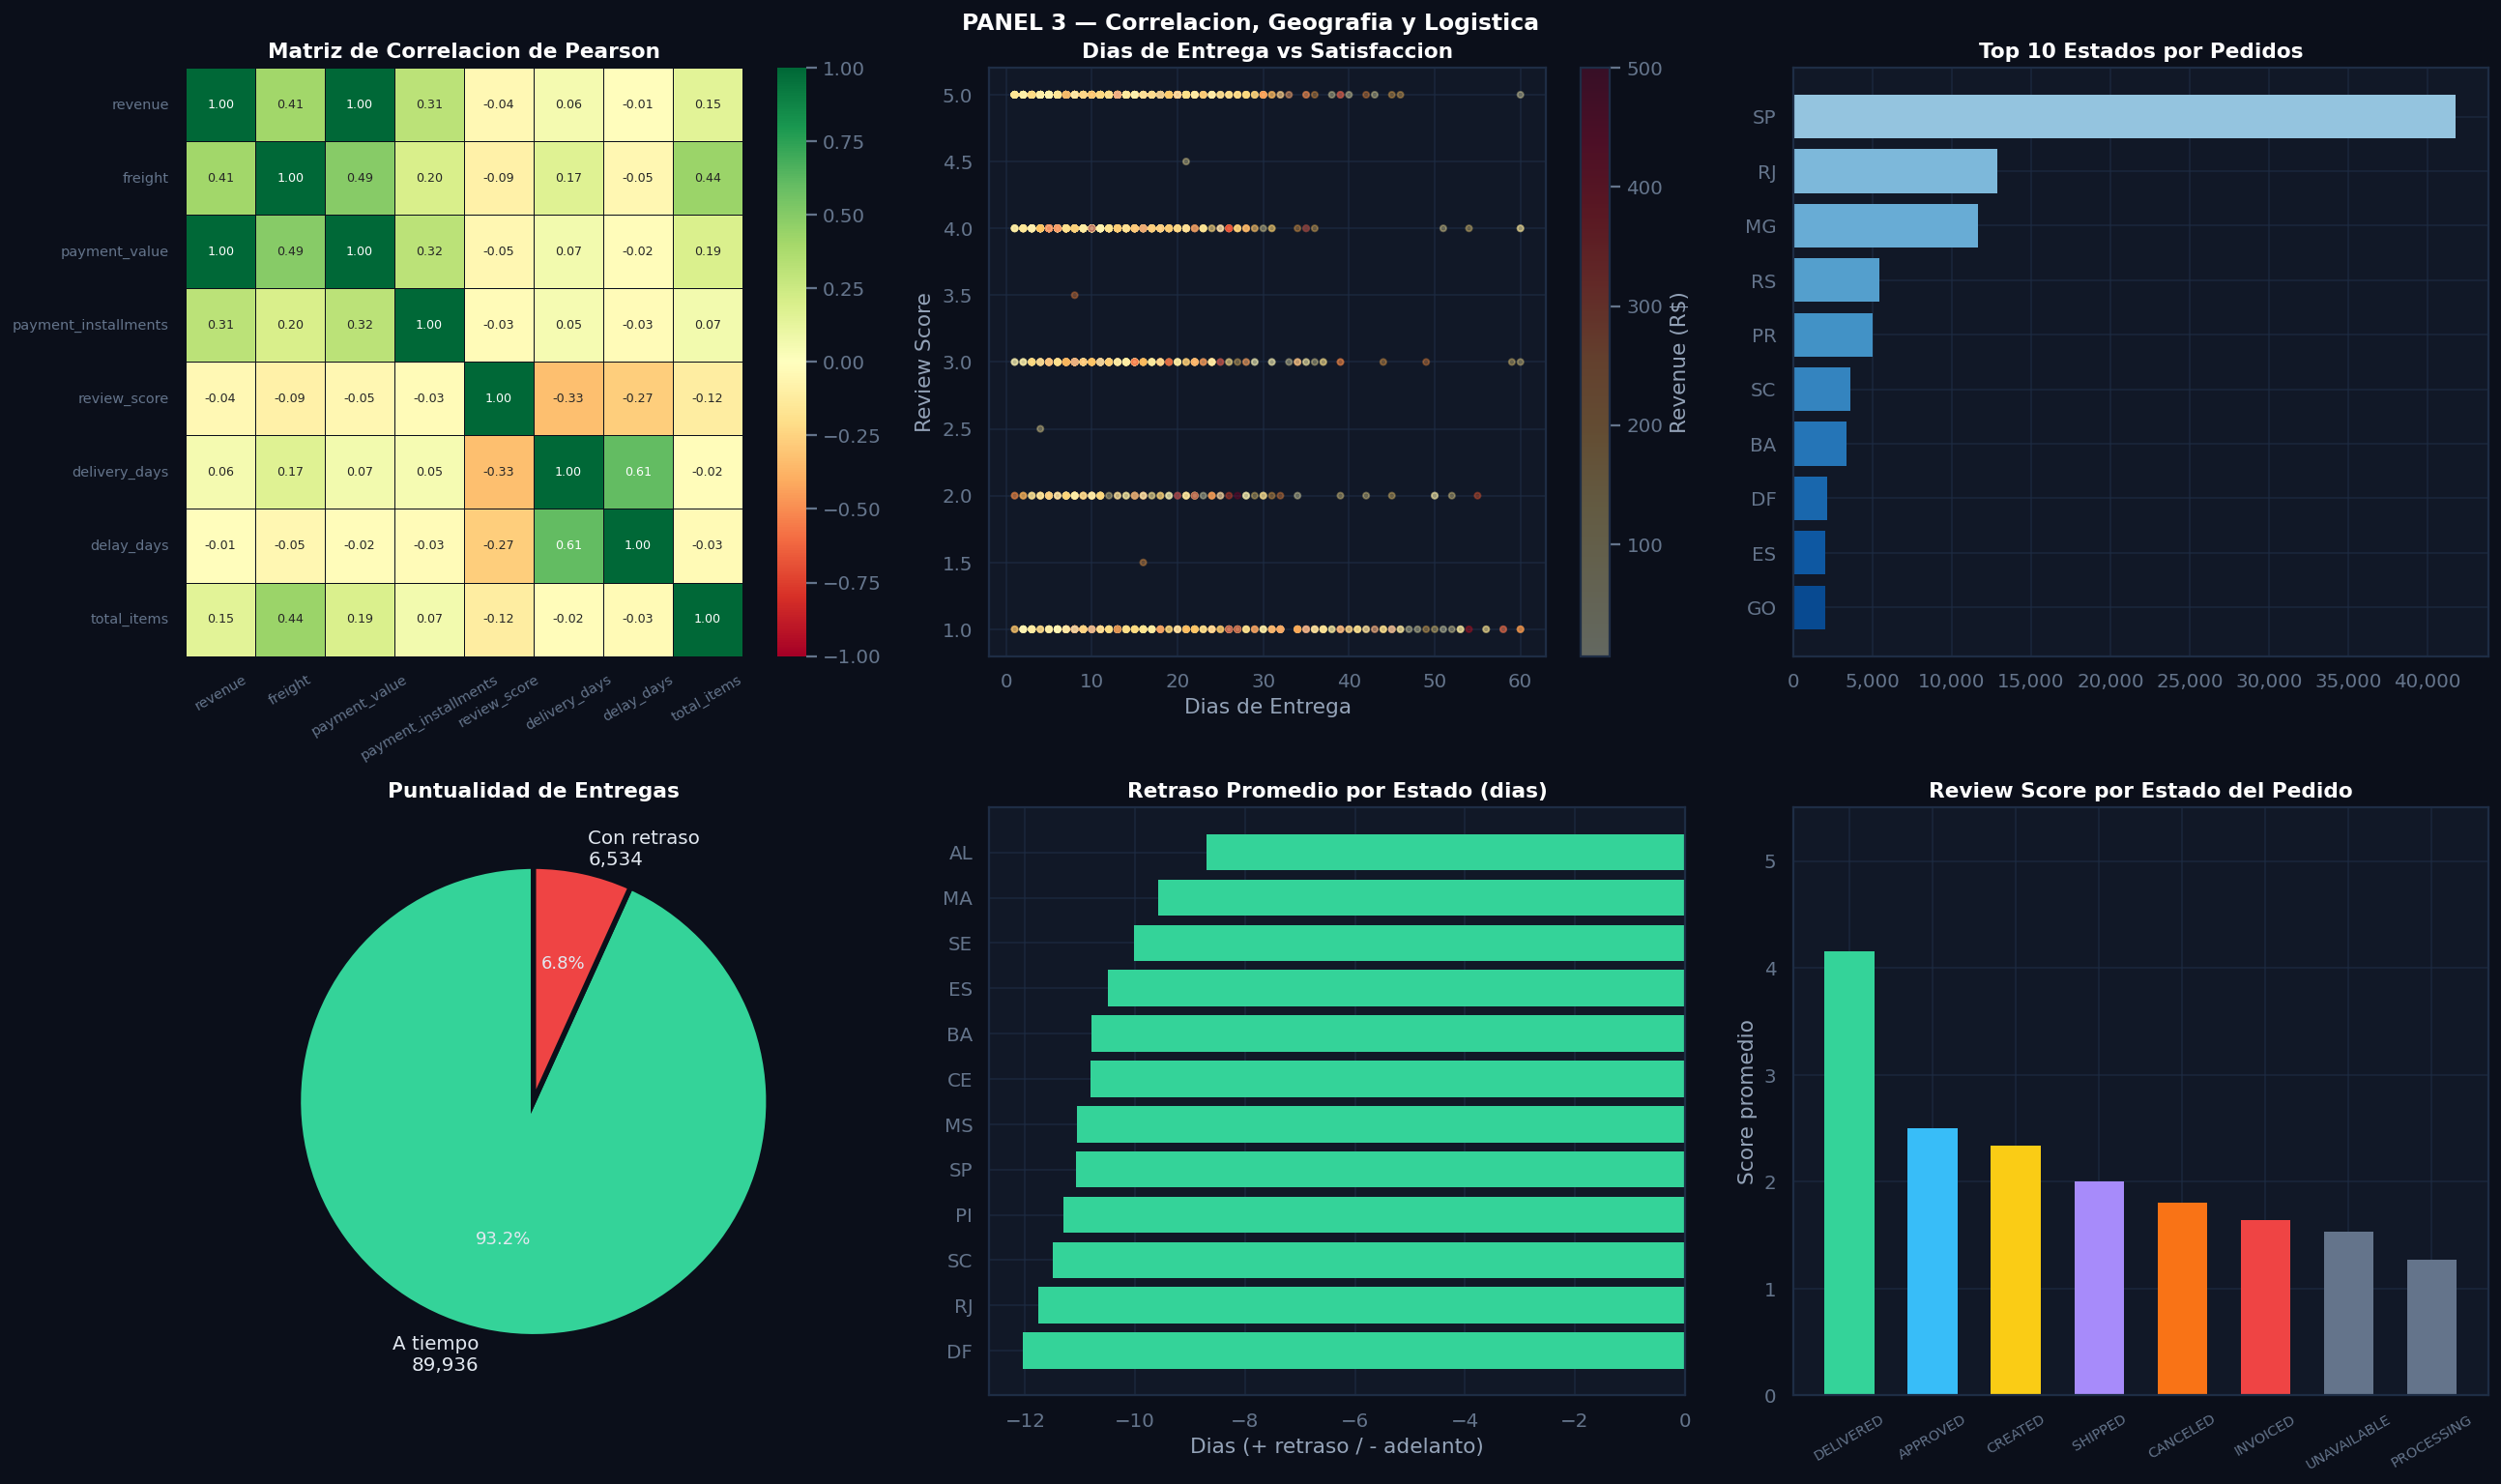

Panel 3 guardado: dashboard_panel3.png

Dashboard completo: 3 paneles generados.
Archivos: dashboard_panel1.png, dashboard_panel2.png, dashboard_panel3.png


In [ ]:
# ═══════════════════════════════════════════════════════
# PANEL 3 — Correlacion + Geografia + Logistica
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0b0f1a')
fig.suptitle('PANEL 3 — Correlacion, Geografia y Logistica',
             color='white', fontsize=13, fontweight='bold')
for ax in axes.flatten(): ax.set_facecolor('#111827')

# Correlacion heatmap
vars_corr = ['revenue','freight','payment_value','payment_installments',
             'review_score','delivery_days','delay_days','total_items']
corr_matrix = df[vars_corr].corr(method='pearson')
mask = np.zeros_like(corr_matrix)
sns.heatmap(
    corr_matrix, ax=axes[0,0],
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.3, linecolor='#0b0f1a',
    annot_kws={'size':7}
)
axes[0,0].set_title('Matriz de Correlacion de Pearson', color='white', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0,0].tick_params(axis='y', rotation=0, labelsize=8)

# Scatter delivery_days vs review_score
sample = df[['delivery_days','review_score','revenue']].dropna().sample(min(4000,len(df)), random_state=42)
sc = axes[0,1].scatter(
    sample['delivery_days'].clip(0,60), sample['review_score'],
    c=sample['revenue'].clip(0,500), cmap='YlOrRd', alpha=0.35, s=12
)
plt.colorbar(sc, ax=axes[0,1], label='Revenue (R$)')
axes[0,1].set_xlabel('Dias de Entrega')
axes[0,1].set_ylabel('Review Score')
axes[0,1].set_title('Dias de Entrega vs Satisfaccion', color='white', fontweight='bold')

# Top 10 estados
top_est = df['customer_state'].value_counts().head(10)
colors_est = plt.cm.Blues(np.linspace(0.4,0.9,10))[::-1]
axes[0,2].barh(top_est.index[::-1], top_est.values[::-1], color=colors_est, edgecolor='none')
axes[0,2].set_title('Top 10 Estados por Pedidos', color='white', fontweight='bold')
axes[0,2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

# Puntualidad donut
entregados = df[(df['order_status']=='DELIVERED') & df['delay_days'].notna()]
n_puntual = (entregados['delay_days'] <= 0).sum()
n_tarde   = (entregados['delay_days']  > 0).sum()
axes[1,0].pie([n_puntual, n_tarde],
              labels=[f'A tiempo\n{n_puntual:,}', f'Con retraso\n{n_tarde:,}'],
              colors=[EMERALD, RED], startangle=90,
              wedgeprops={'edgecolor':'#0b0f1a','linewidth':3},
              autopct='%1.1f%%')
axes[1,0].set_title('Puntualidad de Entregas', color='white', fontweight='bold')

# Retraso por estado
ret_est = entregados.groupby('customer_state')['delay_days'].mean().sort_values(ascending=False).head(12)
colores_ret = [RED if v>0 else EMERALD for v in ret_est.values]
axes[1,1].barh(ret_est.index[::-1], ret_est.values[::-1],
               color=colores_ret[::-1], edgecolor='none')
axes[1,1].axvline(0, color='white', lw=0.8, alpha=0.5)
axes[1,1].set_title('Retraso Promedio por Estado (dias)', color='white', fontweight='bold')
axes[1,1].set_xlabel('Dias (+ retraso / - adelanto)')

# Review score por estado de pedido
score_status = df.groupby('order_status')['review_score'].mean().sort_values(ascending=False)
axes[1,2].bar(score_status.index, score_status.values,
              color=[EMERALD,SKY,YELLOW,VIOLET,ORANGE,RED,MUTED,MUTED][:len(score_status)],
              edgecolor='none', width=0.6)
axes[1,2].set_title('Review Score por Estado del Pedido', color='white', fontweight='bold')
axes[1,2].set_ylabel('Score promedio')
axes[1,2].set_ylim(0, 5.5)
axes[1,2].tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.savefig('dashboard_panel3.png', bbox_inches='tight', facecolor='#0b0f1a')
plt.show()
print('Panel 3 guardado: dashboard_panel3.png')
print('\nDashboard completo: 3 paneles generados.')
print('Archivos: dashboard_panel1.png, dashboard_panel2.png, dashboard_panel3.png')


EE


        

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [ ]:
df = (
    orders
    .merge(customers[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
    .merge(order_items.groupby('order_id').agg(
        total_items=('order_item_id', 'count'),
        revenue=('price', 'sum'),
        freight=('freight_value', 'sum')
    ).reset_index(), on='order_id', how='left')
    .merge(payments.groupby('order_id').agg(
        payment_value=('payment_value', 'sum'),
        payment_installments=('payment_installments', 'max'),
        payment_type=('payment_type', lambda x: x.mode()[0] if len(x) > 0 else 'UNKNOWN')
    ).reset_index(), on='order_id', how='left')
    .merge(reviews.groupby('order_id').agg(
        review_score=('review_score', 'mean')
    ).reset_index(), on='order_id', how='left')
)

df['delivery_days']  = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']     = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['purchase_year']  = df['order_purchase_timestamp'].dt.year

print(f'Dataframe maestro: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataframe maestro: 99,441 filas x 21 columnas


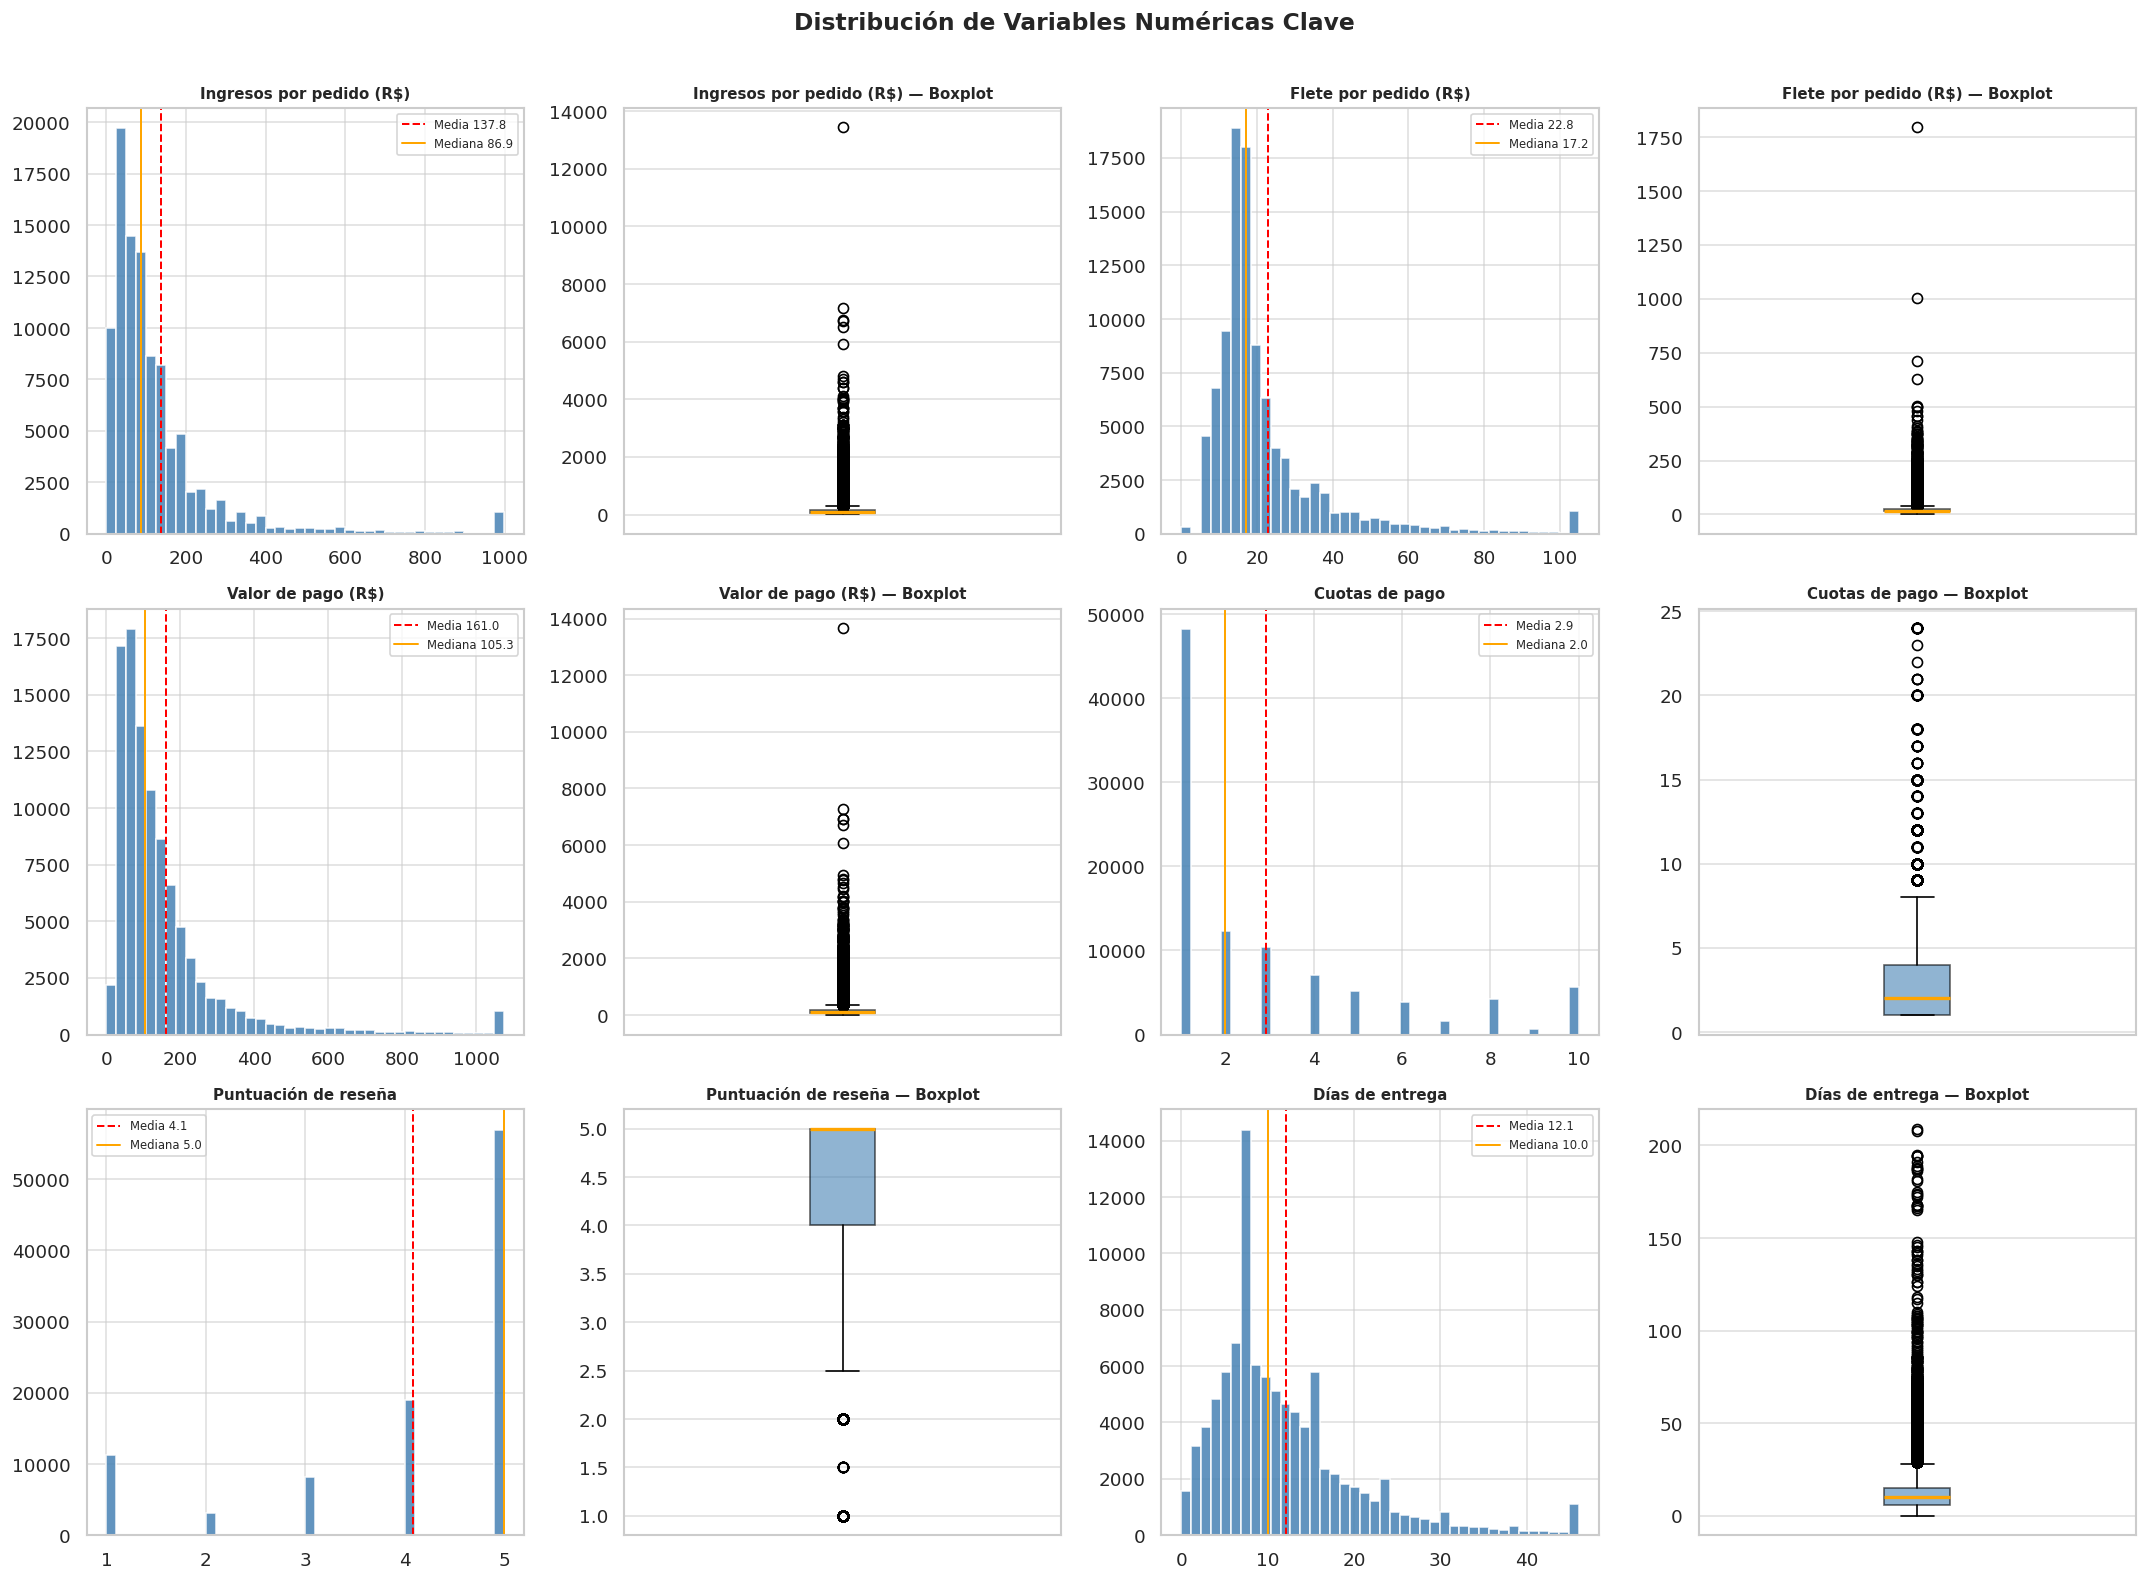

In [ ]:
pares = [
    ('revenue',               'Ingresos por pedido (R$)'),
    ('freight',               'Flete por pedido (R$)'),
    ('payment_value',         'Valor de pago (R$)'),
    ('payment_installments',  'Cuotas de pago'),
    ('review_score',          'Puntuación de reseña'),
    ('delivery_days',         'Días de entrega'),
]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle('Distribución de Variables Numéricas Clave', fontsize=14, fontweight='bold', y=1.01)

for i, (col, label) in enumerate(pares):
    data = df[col].dropna()
    ax_hist = axes[i // 2][(i % 2) * 2]
    ax_box  = axes[i // 2][(i % 2) * 2 + 1]

    # Histograma
    ax_hist.hist(data.clip(upper=data.quantile(0.99)), bins=40,
                 color='steelblue', edgecolor='white', alpha=0.85)
    ax_hist.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2,
                    label=f'Media {data.mean():.1f}')
    ax_hist.axvline(data.median(), color='orange', linestyle='-',  linewidth=1.2,
                    label=f'Mediana {data.median():.1f}')
    ax_hist.set_title(label, fontsize=9, fontweight='bold')
    ax_hist.legend(fontsize=7)

    # Boxplot
    ax_box.boxplot(data.dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='orange', linewidth=2))
    ax_box.set_title(f'{label} — Boxplot', fontsize=9, fontweight='bold')
    ax_box.set_xticks([])

plt.tight_layout()
plt.savefig('viz1_distribuciones.png', bbox_inches='tight')
plt.show()

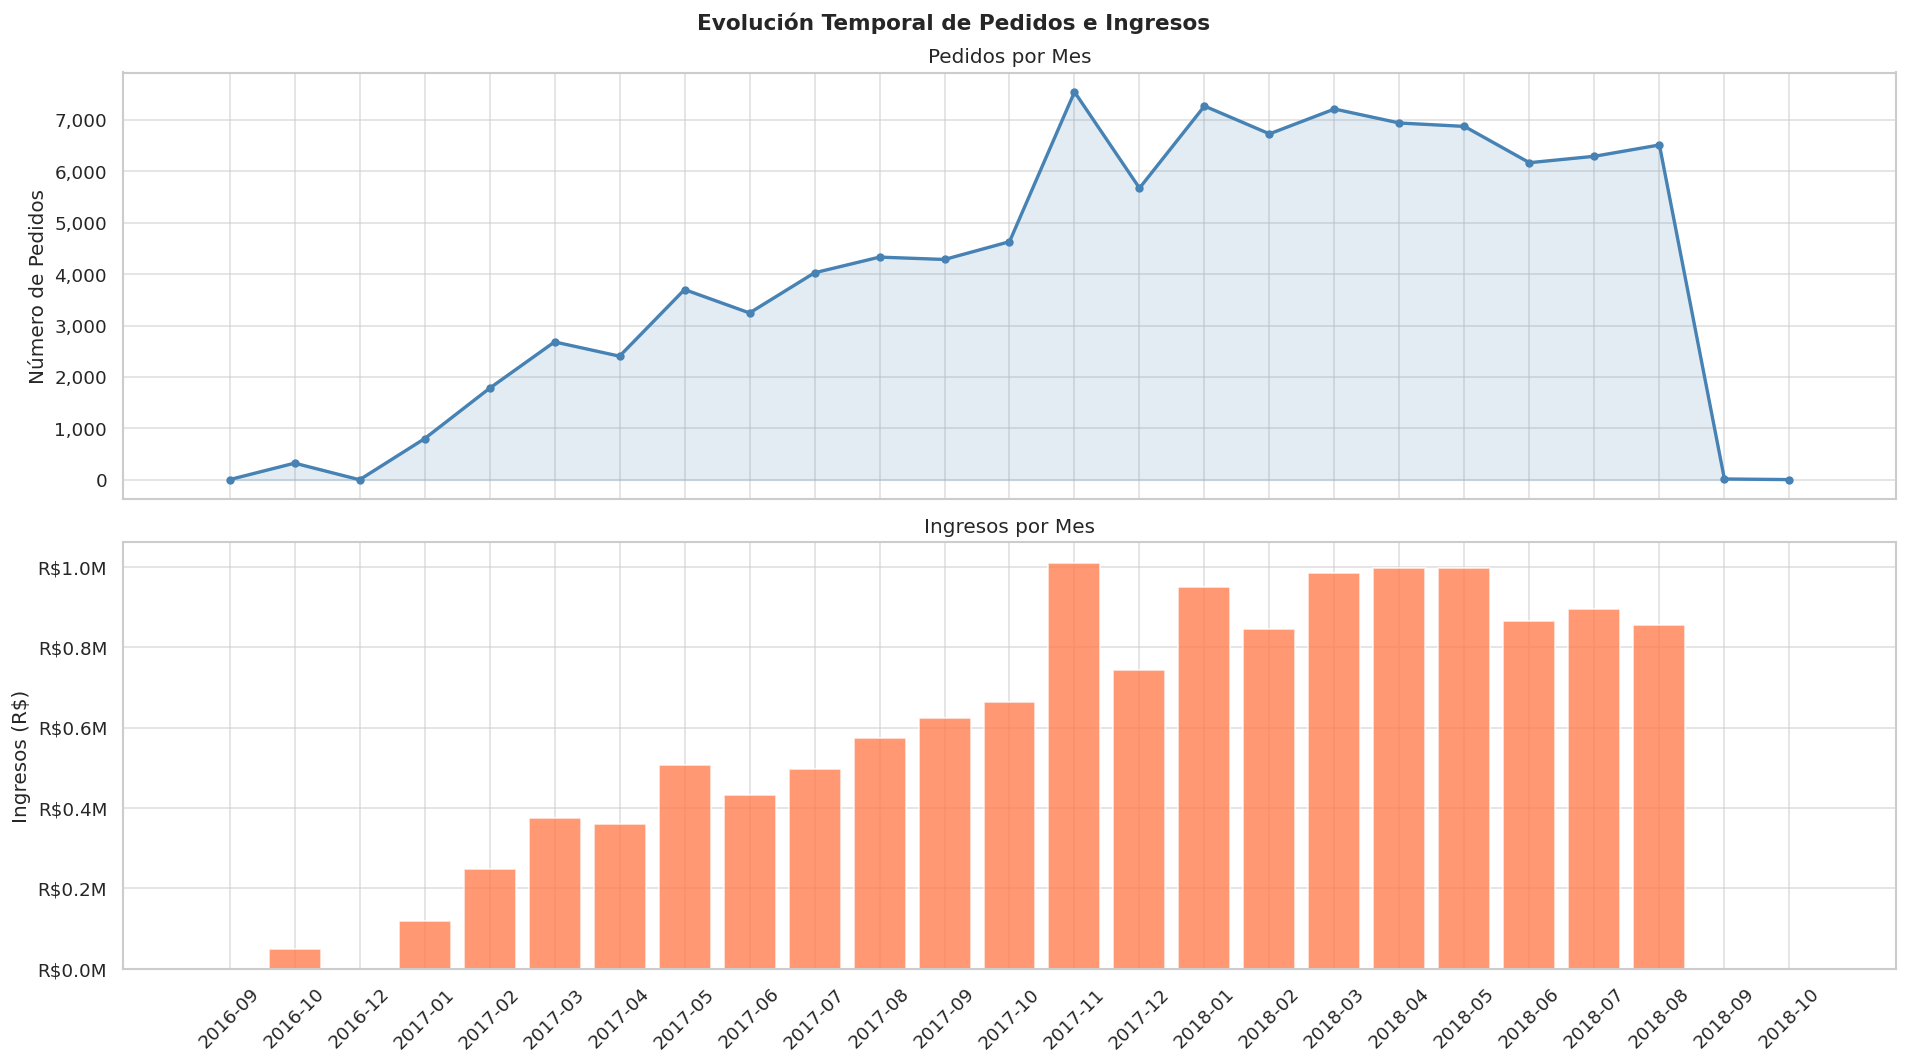

Pico máximo: 2017-11 — 7,544 pedidos


In [ ]:
ventas_mes = (
    df.groupby('purchase_month')
    .agg(pedidos=('order_id', 'count'), ingresos=('revenue', 'sum'))
    .reset_index()
)
ventas_mes['purchase_month_str'] = ventas_mes['purchase_month'].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Evolución Temporal de Pedidos e Ingresos', fontsize=13, fontweight='bold')

# Panel superior — línea de pedidos
ax1.plot(ventas_mes['purchase_month_str'], ventas_mes['pedidos'],
         marker='o', color='steelblue', linewidth=2, markersize=4)
ax1.fill_between(ventas_mes['purchase_month_str'], ventas_mes['pedidos'],
                 alpha=0.15, color='steelblue')
ax1.set_ylabel('Número de Pedidos')
ax1.set_title('Pedidos por Mes')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Panel inferior — barras de ingresos
ax2.bar(ventas_mes['purchase_month_str'], ventas_mes['ingresos'],
        color='coral', alpha=0.8, edgecolor='white')
ax2.set_ylabel('Ingresos (R$)')
ax2.set_title('Ingresos por Mes')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('viz2_temporal.png', bbox_inches='tight')
plt.show()

peak = ventas_mes.loc[ventas_mes['pedidos'].idxmax()]
print(f'Pico máximo: {peak["purchase_month_str"]} — {peak["pedidos"]:,} pedidos')

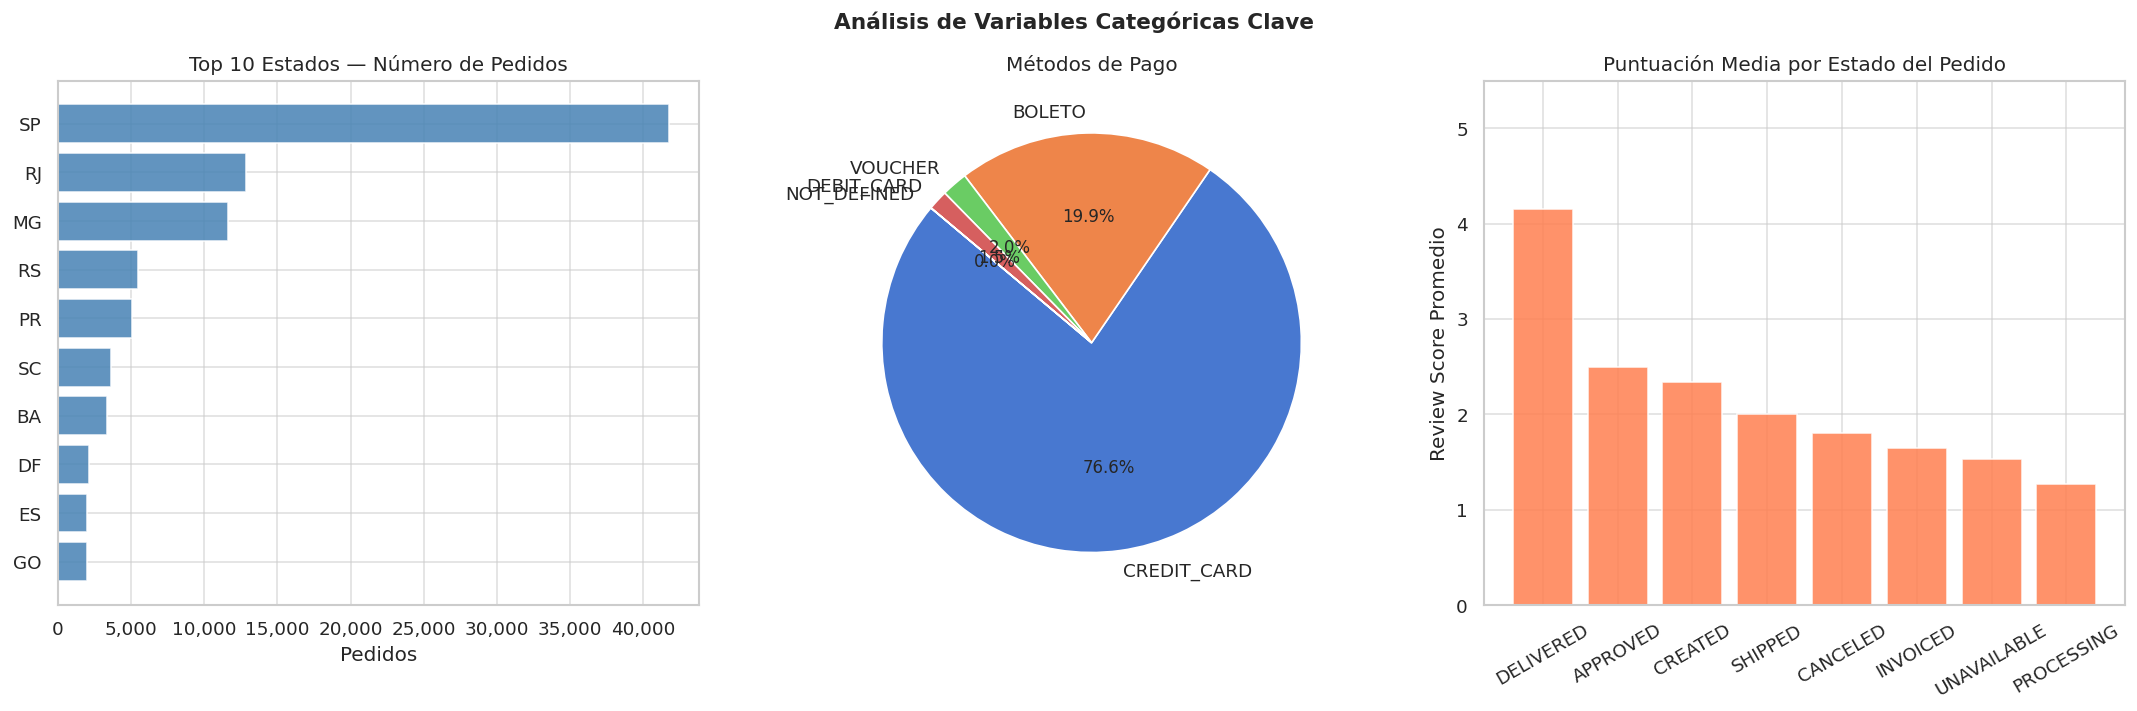

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis de Variables Categóricas Clave', fontsize=13, fontweight='bold')

# Top 10 estados por número de pedidos
top_estados = df['customer_state'].value_counts().head(10)
axes[0].barh(top_estados.index[::-1], top_estados.values[::-1],
             color='steelblue', alpha=0.85)
axes[0].set_title('Top 10 Estados — Número de Pedidos')
axes[0].set_xlabel('Pedidos')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Métodos de pago (torta)
pay_counts = df['payment_type'].value_counts()
axes[1].pie(pay_counts.values,
            labels=pay_counts.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(pay_counts)),
            startangle=140)
axes[1].set_title('Métodos de Pago')

# Puntuación media por estado del pedido
score_status = df.groupby('order_status')['review_score'].mean().sort_values(ascending=False)
axes[2].bar(score_status.index, score_status.values,
            color='coral', alpha=0.85, edgecolor='white')
axes[2].set_title('Puntuación Media por Estado del Pedido')
axes[2].set_ylabel('Review Score Promedio')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('viz3_categorico.png', bbox_inches='tight')
plt.show()


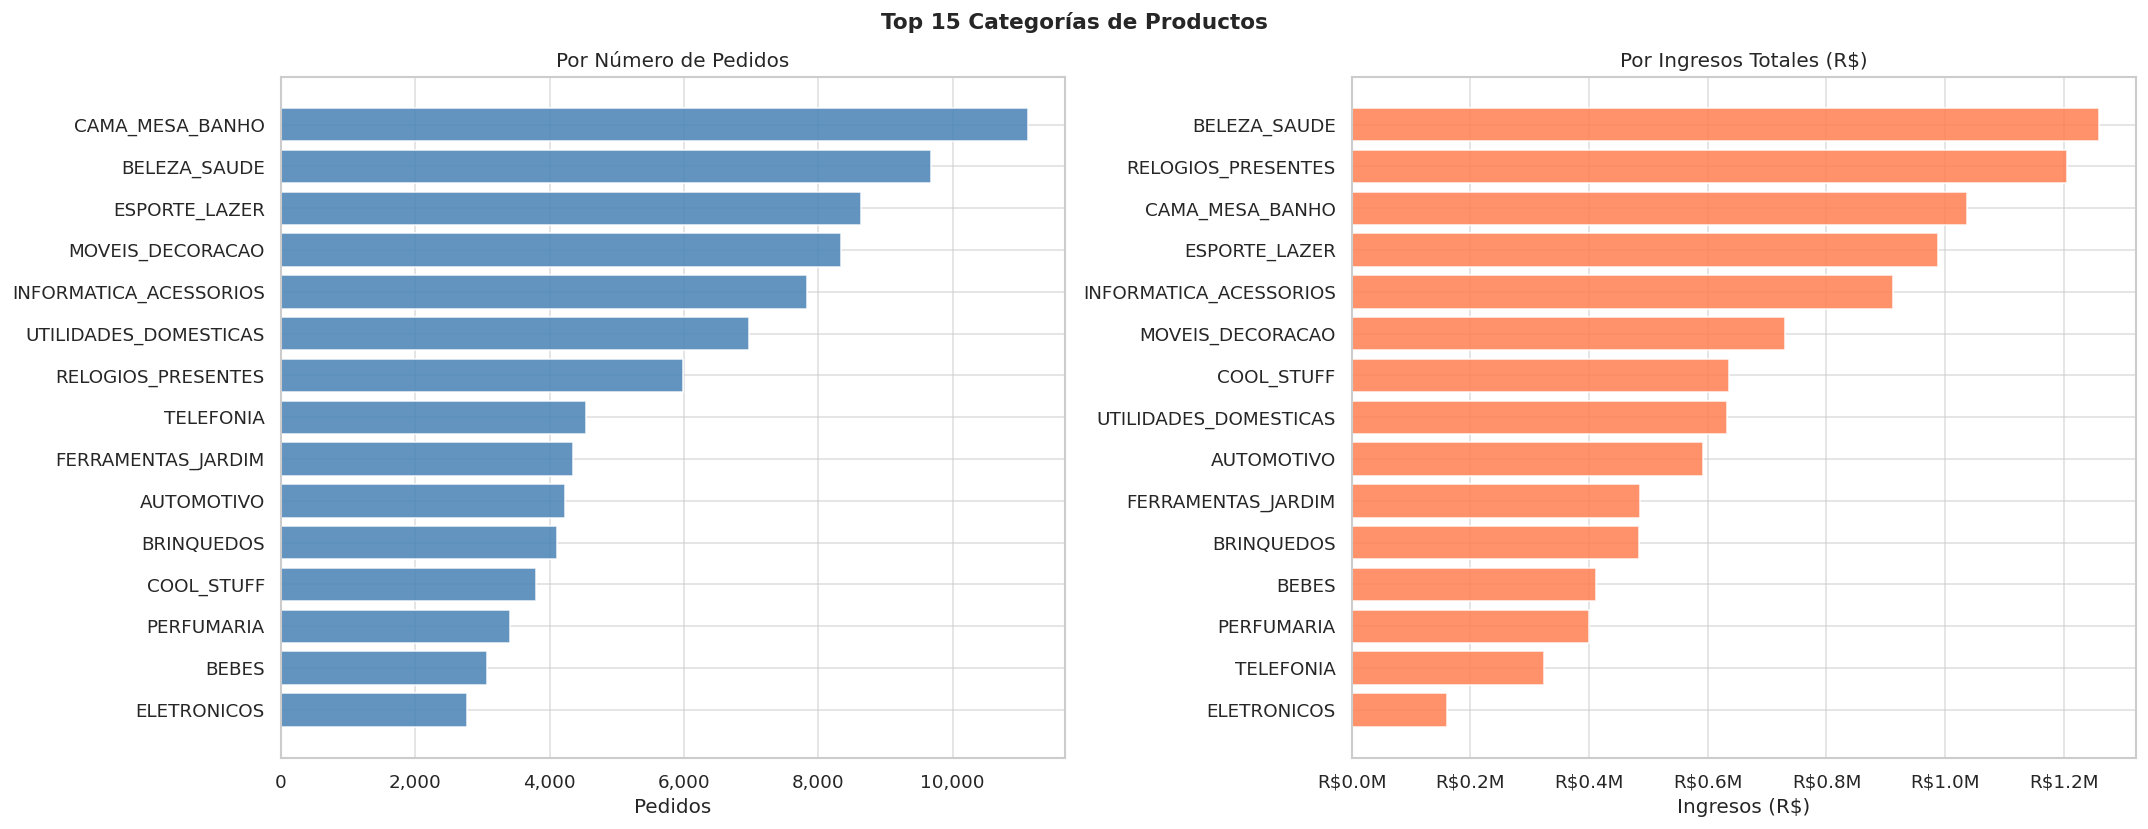

In [ ]:
items_cat = (
    order_items
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(category_translation, on='product_category_name', how='left')
)

# Usar traducción al inglés si está disponible
cat_label = 'product_category_name_english'
if items_cat[cat_label].isna().sum() > items_cat['product_category_name'].isna().sum():
    cat_label = 'product_category_name'

top_cats = (
    items_cat.groupby(cat_label)
    .agg(pedidos=('order_id', 'count'), ingresos=('price', 'sum'))
    .sort_values('pedidos', ascending=False)
    .head(15)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 15 Categorías de Productos', fontsize=13, fontweight='bold')

# Por número de pedidos
ax1.barh(top_cats.index[::-1], top_cats['pedidos'][::-1],
         color='steelblue', alpha=0.85)
ax1.set_title('Por Número de Pedidos')
ax1.set_xlabel('Pedidos')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Por ingresos totales
top_ing = top_cats.sort_values('ingresos', ascending=False).head(15)
ax2.barh(top_ing.index[::-1], top_ing['ingresos'][::-1],
         color='coral', alpha=0.85)
ax2.set_title('Por Ingresos Totales (R$)')
ax2.set_xlabel('Ingresos (R$)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('viz4_categorias.png', bbox_inches='tight')
plt.show()